# SC-RLOT v2 — Multi-Cohort AML Drug-Resistance Detector (Colab Pro Edition)
### Single-Cell Reinforcement Learning for Optimal Treatment

**Sections:** 1. Setup  2. Data loading & labels  3. Drug panel (GDSC)  4. VAE  5. GATv2 classifier + baselines  6. RL (PPO)  7. SHAP explainability  8. Clinical validation (Beat AML)  9. MLflow  10. Export

> Run top-to-bottom on first use. On every reconnect, just re-run **1.1** (install) and **1.2/1.3** (imports + mount) — checkpointed stages detect existing Drive artifacts and skip retraining unless `FORCE_RETRAIN = True`.

**Fixes applied in this version:** GSE116256 patients partially folded into training (was zero-shot-only, now ~11 patients contribute labels, 5 held out); GATv2Lite added as a lower-capacity variant to test overfitting; RandomForest ensemble + bootstrap 95% CI on the GATv2-vs-RF AUC difference; Beat AML Cox model no longer hard-blocks on missing columns and uses `resist_score` as a `SHAP_score` fallback; unnecessary standalone diagnostic cells removed.

**Additional fixes in this cleanup pass:** consolidated the Wegmann (2.2c) debugging cascade -- 15 cells, 3 of them crashing (`RuntimeError` on `write_h5ad`, `NameError: old_path`, `KeyError: 'resistant'` from a label merge that had been re-run twice) -- into 8 clean, idempotent cells; fixed the root-cause `anndata` nullable-string write error globally (1.2); removed two duplicate `FORCE_RETRAIN = True` cells that silently forced a full retrain on every run and defeated the Drive-checkpoint skip logic described above; fixed a hardcoded `'X_pca_harmony'` key in 2.6.2 that would `KeyError` if Harmony batch correction had fallen back to plain PCA; replaced a hardcoded Drive path in 2.2b with `PROJECT_ROOT`; and wired `GATv2Micro` (already trained in 5.3, previously dropped) into the 5.4 plot, 5.5 baseline table, and 9.1/9.2 MLflow logging/summary.

## 1.1 — Install packages
All pip installs consolidated into one cell (previously split across three cells). Colab's pre-installed numpy can't be hot-swapped mid-process, so this cell force-restarts the runtime once after installing — that's expected, not a crash. Just run the next cell afterward.

In [1]:
# --- Install every package this notebook needs, once, with an idempotency guard
# so a kernel restart mid-install doesn't loop forever. ---
import os

MARKER = '/content/.sc-rlot_pkgs_installed'

if os.path.exists(MARKER):
    print('Packages already installed and runtime already restarted in this session.')
    print('Nothing to do here -- go run the NEXT cell (1.2 imports).')
else:
    import torch
    print('Torch:', torch.__version__, '| CUDA:', torch.version.cuda, '| GPU available:', torch.cuda.is_available())

    get_ipython().system('pip -q install torch_geometric')
    get_ipython().system('pip -q install pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html')
    get_ipython().system('pip -q install scanpy anndata scikit-learn')
    get_ipython().system('pip -q install "harmonypy==0.0.10" scikit-misc')  # pinned version + HVG dependency
    get_ipython().system('pip -q install "stable-baselines3[extra]" gymnasium')
    get_ipython().system('pip -q install shap xgboost mlflow lifelines')
    get_ipython().system('pip -q install GEOparse')

    print('Install complete.')

    with open(MARKER, 'w') as f:
        f.write('done')

    # ------------------------------------------------------------------
    # The installs above silently upgrade numpy. Colab's kernel already has
    # an OLDER numpy loaded in the live process, and numpy's C extensions
    # cannot be hot-swapped mid-process -- so the next `import numpy` in
    # THIS session would crash. Force one restart now so the fresh packages
    # load cleanly. This is expected to look like a crash; happens only once.
    # ------------------------------------------------------------------
    print('Restarting runtime ONCE to load freshly-installed packages cleanly...')
    print('This cell will appear to fail -- that is expected. Just run the next cell now.')
    os.kill(os.getpid(), 9)


Packages already installed and runtime already restarted in this session.
Nothing to do here -- go run the NEXT cell (1.2 imports).


## 1.2 — Imports & global settings
Core imports, device detection, global seed, drug panel placeholder (auto-selected for real in 3.3), toxicity priors, curated gene panel.

In [2]:
# --- Core imports, device (CPU/GPU) detection, global seed ---
import os, sys, gc, json, random, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
# Fix: newer anndata (>=0.11) refuses to write pandas nullable/Arrow string
# columns to .h5ad unless this is set explicitly -- without it, EVERY
# write_h5ad() call below that touches a merged/string obs column can raise
# `RuntimeError: anndata.settings.allow_write_nullable_strings is None ...`
# Set once, globally, here, so no downstream write_h5ad call needs to worry about it.
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

# NOTE: DRUG_LIST/TOXICITY here are placeholders -- 3.3 overwrites DRUG_LIST with
# whatever 5 AML-approved drugs actually have real GDSC1/2 coverage. Kept here
# only so early cells that reference DRUG_LIST/TOXICITY don't error before 3.3 runs.
DRUG_LIST = ['Venetoclax', 'Gilteritinib', 'Panobinostat', 'Azacitidine', 'Quizartinib']
DRUG_INDEX = {d: i for i, d in enumerate(DRUG_LIST)}
TOXICITY = np.array([0.40, 0.35, 0.50, 0.45, 0.40])  # Ven, Gilt, Pano, Aza, Quiz -- literature-informed priors

CURATED_PANEL = {
    "BCL2", "MCL1", "BCL2L1", "BCL2L11", "BAX", "BAK1",        # Venetoclax axis
    "FLT3", "STAT5A", "STAT5B", "PIK3CA",                       # Gilteritinib/Quizartinib axis
    "HDAC1", "HDAC2", "HDAC3", "EP300",                         # Panobinostat axis
    "DNMT3A", "TET2", "IDH1", "IDH2",                            # Azacitidine axis (methylation)
    "TP53", "MYC", "CDKN1A", "CDKN2A", "MDM2",                  # General AML resistance
    "RELA", "NFKB1", "IKBKB", "RELB", "NFKBIA",                 # NF-kB
    "CD3D", "CD8A", "NKG7", "GNLY", "MS4A1", "CD14",            # Immune/cell-type markers
    "CD36", "CLPB", "PMAIP1", "BIK", "PLK1", "CD34",            # Wegmann et al. 2024 (Nat Commun) --
                                                                  # externally-validated VEN-resistance genes
}

FORCE_RETRAIN = False  # set True to ignore existing Drive checkpoints and retrain from scratch

print(f'Drug panel (placeholder, overwritten in 3.3): {DRUG_LIST}')
print(f'Curated gene panel size: {len(CURATED_PANEL)}')


Using device: cuda
Drug panel (placeholder, overwritten in 3.3): ['Venetoclax', 'Gilteritinib', 'Panobinostat', 'Azacitidine', 'Quizartinib']
Curated gene panel size: 40


## 1.3 — Mount Google Drive + persistent project structure
Everything under `PROJECT_ROOT` survives session resets and disconnects -- local `/content` does not.

In [3]:
# --- Mount Google Drive, create persistent project folder structure ---
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/SC-RLOT'
SUBDIRS = [
    'data/raw', 'data/processed', 'data/cohorts',
    'models/vae', 'models/gatv2', 'models/ppo', 'models/baselines',
    'mlruns', 'mlartifacts', 'artifacts', 'checkpoints/vae',
    'checkpoints/gatv2', 'checkpoints/ppo', 'figures', 'logs',
]
for sub in SUBDIRS:
    os.makedirs(f'{PROJECT_ROOT}/{sub}', exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Persistent structure ready.')

import shutil
total, used, free = shutil.disk_usage('/content/drive/MyDrive')
print(f'Drive free space: {free / 1e9:.1f} GB (budget 40-50GB for the full 4-cohort run)')


Mounted at /content/drive
Project root: /content/drive/MyDrive/SC-RLOT
Persistent structure ready.
Drive free space: 64.1 GB (budget 40-50GB for the full 4-cohort run)


## 1.4 — Dataset configuration
- `GSE156041` / `GSE143363` -- Jordan lab (Nature Cancer) single-cell RNA-seq of real AML leukemia stem cells profiled for intrinsic and acquired venetoclax+azacitidine resistance. Training arm. **Replaces `GSE220112`**, which was discovered to be a B-ALL (not AML) cell line (RS4;11, confirmed against its GEO record) and has been removed entirely -- see the note in 2.3 on verifying real sample titles before trusting the derived label.
- `GSE116256` -- 16 real AML patients. **~11 patients now folded into training** (D0-vs-on-treatment proxy label), 5 held out as a true zero-shot arm. See 2.6 for the labeling logic.
- `TP53_VEN_COHORT` -- 3 patients, longitudinal pre/post venetoclax. Training arm.

In [4]:
# ============================================================
# DATASET CONFIGURATION
# ============================================================
DATASET_CONFIG = {
    # GSE220112 removed: its cell line (RS4;11) is B-ALL, not AML (confirmed
    # against the GEO record) -- it cannot validly serve as an AML training
    # cohort under any label. Replaced with two real AML LSC venetoclax
    # resistance cohorts from the same disease and drug mechanism this
    # project actually studies.
    'GSE156041': {
        'role': 'train', 'geo_accession': 'GSE156041', 'label_col': None,
        # label_col is None because these cohorts don't ship a ready-made
        # per-cell label column -- 2.3 extracts 'sample_name' from the raw
        # file names, and 2.6 derives 'resistant' from it. VERIFY the printed
        # sample names in 2.3 against the actual GEO sample titles before
        # trusting the label -- this mirrors exactly how GSE116256 was handled.
        'is_cell_line': False, 'n_patients': None,  # confirm after download, see 2.3 printout
    },
    'GSE143363': {
        'role': 'train', 'geo_accession': 'GSE143363', 'label_col': None,
        'is_cell_line': False, 'n_patients': None,  # confirm after download, see 2.3 printout
    },
    'GSE116256': {
        # role is nominally 'zero_shot_test' here for downloading purposes;
        # the ACTUAL per-cell train/holdout split happens in 2.6 based on
        # patient-level assignment, once real labels are derived.
        'role': 'zero_shot_test', 'geo_accession': 'GSE116256', 'label_col': None,
        'is_cell_line': False, 'n_patients': 16,
    },
}

USE_BHATT = False          # pending EGA DAC access
USE_TP53_COHORT = True

if USE_BHATT:
    DATASET_CONFIG['BHATT_2024'] = {
        'role': 'train', 'label_col': 'venetoclax_response',
        'is_cell_line': False, 'n_patients': 21,
        'local_path': f'{PROJECT_ROOT}/data/raw/bhatt',
    }
if USE_TP53_COHORT:
    DATASET_CONFIG['TP53_VEN_COHORT'] = {
        'role': 'train', 'geo_accession': 'GSE306339', 'label_col': 'venetoclax_response',
        'is_cell_line': False, 'n_patients': 3,
    }

USE_WEGMANN = True        # Wegmann et al. 2024 (Nat Commun, TuPro) -- real PCY-based VEN response
if USE_WEGMANN:
    DATASET_CONFIG['WEGMANN_2024'] = {
        'role': 'train', 'label_col': 'resistant',
        'is_cell_line': False, 'n_patients': 14,
        'local_path': f'{PROJECT_ROOT}/data/raw/wegmann',
    }

TRAIN_COHORTS = [k for k, v in DATASET_CONFIG.items() if v['role'] == 'train']
TEST_COHORTS  = [k for k, v in DATASET_CONFIG.items() if v['role'] == 'zero_shot_test']

print('Training cohorts (used for gradients):', TRAIN_COHORTS)
print('Zero-shot test cohorts (nominal, see 2.6 for GSE116256 partial fold-in):', TEST_COHORTS)


Training cohorts (used for gradients): ['GSE156041', 'GSE143363', 'TP53_VEN_COHORT', 'WEGMANN_2024']
Zero-shot test cohorts (nominal, see 2.6 for GSE116256 partial fold-in): ['GSE116256']


## 2.1 — Download raw GEO cohorts
GEOparse pulls series metadata + supplementary matrix files per cohort. Exact loader logic (10x mtx vs. pre-processed counts vs. h5) depends on how each GEO series packages its data -- handled per-cohort in 2.3.

In [5]:
# ============================================================
# 2.1 -- Download / locate raw per-cohort files
# ============================================================
import GEOparse

def download_geo_supp(accession, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    marker = os.path.join(out_dir, '.download_complete')
    if os.path.exists(marker) and not FORCE_RETRAIN:
        print(f'[{accession}] already downloaded -> {out_dir}')
        return out_dir
    print(f'[{accession}] downloading supplementary files (this can take a while)...')
    gse = GEOparse.get_GEO(geo=accession, destdir=out_dir, silent=True)
    gse.download_supplementary_files(directory=out_dir)
    with open(marker, 'w') as f:
        f.write('ok')
    return out_dir

RAW_DIR = f'{PROJECT_ROOT}/data/raw'
for name, cfg in DATASET_CONFIG.items():
    if 'geo_accession' in cfg:
        cfg['local_path'] = download_geo_supp(cfg['geo_accession'], f'{RAW_DIR}/{name}')

print('\nAll configured raw cohort paths:')
for name, cfg in DATASET_CONFIG.items():
    print(f"  {name}: {cfg.get('local_path')}")


[GSE156041] already downloaded -> /content/drive/MyDrive/SC-RLOT/data/raw/GSE156041
[GSE143363] already downloaded -> /content/drive/MyDrive/SC-RLOT/data/raw/GSE143363
[GSE116256] already downloaded -> /content/drive/MyDrive/SC-RLOT/data/raw/GSE116256
[GSE306339] already downloaded -> /content/drive/MyDrive/SC-RLOT/data/raw/TP53_VEN_COHORT

All configured raw cohort paths:
  GSE156041: /content/drive/MyDrive/SC-RLOT/data/raw/GSE156041
  GSE143363: /content/drive/MyDrive/SC-RLOT/data/raw/GSE143363
  GSE116256: /content/drive/MyDrive/SC-RLOT/data/raw/GSE116256
  TP53_VEN_COHORT: /content/drive/MyDrive/SC-RLOT/data/raw/TP53_VEN_COHORT
  WEGMANN_2024: /content/drive/MyDrive/SC-RLOT/data/raw/wegmann


## 2.2 — GSE116256-specific download (tar via wget) + extraction
GSE116256 ships as one combined RAW.tar rather than per-file GEOparse downloads, so it needs a dedicated fetch step.

In [6]:
# --- GSE116256: download+extract the combined RAW.tar (idempotent) ---
import subprocess

geo_dir = f'{PROJECT_ROOT}/data/raw/GSE116256'
tar_path = f'{geo_dir}/GSE116256_RAW.tar'
extracted_dir = f'{geo_dir}/extracted'

if not os.path.exists(f'{extracted_dir}/.done'):
    download_url = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE116256&format=file'
    result = subprocess.run(['wget', '-q', '--show-progress', download_url, '-O', tar_path],
                             capture_output=True, text=True)
    if result.returncode != 0:
        print('wget failed, stderr:'); print(result.stderr)
        raise RuntimeError('Download failed -- see stderr above')

    os.makedirs(extracted_dir, exist_ok=True)
    subprocess.run(['tar', '-xf', tar_path, '-C', extracted_dir], check=True)
    with open(f'{extracted_dir}/.done', 'w') as f:
        f.write('ok')
    print('Downloaded and extracted GSE116256_RAW.tar')
else:
    print('Already extracted, skipping download.')


Already extracted, skipping download.


## 2.2b — Direct RAW.tar download for GSE156041 / GSE143363
GEOparse's `download_supplementary_files()` in 2.1 returns nothing for these two series (confirmed empirically -- only the metadata `.soft.gz` downloads, 0 bytes of actual data). This is the same failure mode GSE116256 hit, which is why 2.2 exists as a direct-download workaround for it. Applying the identical fix here: pull each series' combined `RAW.tar` straight from NCBI and extract it, bypassing GEOparse's supplementary-file mechanism entirely for these two cohorts.


In [7]:
import subprocess, os, re

def geo_suppl_url(accession):
    prefix = accession[:-3] + 'nnn'          # GSE156041 -> GSE156nnn
    return f'https://ftp.ncbi.nlm.nih.gov/geo/series/{prefix}/{accession}/suppl/'

def download_geo(accession, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    suppl_url = geo_suppl_url(accession)
    print(f'[{accession}] listing {suppl_url}')
    listing = subprocess.run(['wget', '-q', '-O', '-', suppl_url], capture_output=True, text=True)
    files = re.findall(r'href="([^"/][^"]*\.(?:tar|gz|txt|h5|mtx\.gz|tsv\.gz|csv\.gz))"', listing.stdout)
    if not files:
        print(f'[{accession}] NOTHING found — series may only expose per-GSM files, not series-level suppl.')
        print('Raw listing head:', listing.stdout[:400])
        return []
    print(f'[{accession}] found {len(files)} file(s):', files[:10])
    for fname in files:
        out_path = os.path.join(dest_dir, fname)
        r = subprocess.run(['wget', '-q', suppl_url + fname, '-O', out_path], capture_output=True, text=True)
        size = os.path.getsize(out_path) if os.path.exists(out_path) else 0
        print(f'  {fname}: {size} bytes' + (' -- FAILED' if size == 0 else ''))
    return files

for acc in ['GSE156041', 'GSE143363']:
    # Fix: was hardcoded to '/content/drive/MyDrive/SC-RLOT/...' -- only ever
    # worked because that happened to match PROJECT_ROOT's current value.
    # Use PROJECT_ROOT directly so this can't silently drift out of sync.
    download_geo(acc, f'{PROJECT_ROOT}/data/raw/{acc}')

[GSE156041] listing https://ftp.ncbi.nlm.nih.gov/geo/series/GSE156nnn/GSE156041/suppl/
[GSE156041] found 1 file(s): ['GSE156041_count_matrix.tsv.gz']
  GSE156041_count_matrix.tsv.gz: 46628587 bytes
[GSE143363] listing https://ftp.ncbi.nlm.nih.gov/geo/series/GSE143nnn/GSE143363/suppl/
[GSE143363] found 2 file(s): ['GSE143363_cell_metadata.tsv.gz', 'GSE143363_count_matrix.tsv.gz']
  GSE143363_cell_metadata.tsv.gz: 214211 bytes
  GSE143363_count_matrix.tsv.gz: 11766704 bytes


## 2.2c — Wegmann et al. 2024 (Nat Commun, TuPro cohort): download + R→h5ad conversion + real PCY-based label construction

14 real venetoclax-profiled patients (of 21 total; 14 have paired scRNA-seq + ex-vivo drug response). Label is a continuous PCY ex-vivo response score, median-split into `resistant` -- a real pharmacological readout, not a timepoint proxy like the other three cohorts.

### 2.2c.1 — Download RDS + convert R `SingleCellExperiment` → Python AnnData

In [8]:
import os

WEGMANN_DIR = DATASET_CONFIG['WEGMANN_2024']['local_path']
os.makedirs(WEGMANN_DIR, exist_ok=True)
WEGMANN_RDS = f'{WEGMANN_DIR}/wegmann_scrnaseq.rds'

if not os.path.exists(WEGMANN_RDS):
    # Replace <EXACT_FILENAME> with whatever Step 1 printed for the scRNA-seq file
    get_ipython().system(f'wget -q "https://zenodo.org/records/13837019/files/TuPro_AML_scRNA_counts_all_samples_SCE.RDS" -O {WEGMANN_RDS}')
    print('Downloaded:', os.path.getsize(WEGMANN_RDS), 'bytes')
else:
    print('Already downloaded.')

Already downloaded.


In [9]:
get_ipython().system('pip -q install anndata2ri rpy2 --break-system-packages')

In [10]:
%load_ext rpy2.ipython

import anndata2ri


In [11]:
%%R
if (!require("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", repos = "https://cloud.r-project.org")
}
BiocManager::install("SingleCellExperiment", update = FALSE, ask = FALSE)
library(SingleCellExperiment)
print("SingleCellExperiment installed and loaded successfully!")

[1] "SingleCellExperiment installed and loaded successfully!"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/RtmpLviC4Z/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'BiocVersion', 'SingleCellExperiment'
also installing the dependencies ‘matrixStats’, ‘abind’, ‘XVector’, ‘MatrixGenerics’, ‘Biobase’, ‘IRanges’, ‘Seqinfo’, ‘S4Arrays’, ‘SparseArray’, ‘SummarizedExperiment’, ‘S4Vectors’, ‘BiocGenerics’, ‘GenomicRanges’, ‘DelayedArray’

trying URL 'https://cran.rstudio.com/src/contrib/matrixStats_1.5.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/

In [12]:
%%R -i WEGMANN_RDS -o wegmann_adata_r
library(SingleCellExperiment)
sce <- readRDS(WEGMANN_RDS)
wegmann_adata_r <- sce


In [13]:
import anndata2ri
from rpy2.robjects import conversion

# Convert the RS4 object to a Python AnnData object
with conversion.localconverter(anndata2ri.converter):
    wegmann_adata = conversion.rpy2py(wegmann_adata_r)

wegmann_adata.var_names_make_unique()

print("wegmann_adata is now a Python AnnData object")
print(wegmann_adata)
print('X matrix type:', wegmann_adata.X.__class__)
print('sample_id present:', 'sample_id' in wegmann_adata.obs.columns)

wegmann_adata is now a Python AnnData object
AnnData object with n_obs × n_vars = 81000 × 15454
    obs: 'barcodes', 'fractionMT', 'n_umi', 'n_gene', 'log_umi', 'g2m_score', 's_score', 'cycle_phase', 'celltype_major_full_ct_name', 'celltype_major', 'celltype_final_full_ct_name', 'celltype_final', 'sample_id'
    var: 'gene_ids', 'gene_names'
    layers: None (.X)
X matrix type: <class 'numpy.ndarray'>
sample_id present: True


### 2.2c.2 — Build real PCY-based resistance labels from Supplementary Data 1 & 9

**Before running this cell:** manually download Supplementary Data 1 (`41467_2024_53535_MOESM4_ESM.xlsx`) and Supplementary Data 9 (`41467_2024_53535_MOESM12_ESM.xlsx`) from https://www.nature.com/articles/s41467-024-53535-4 and place both directly in `{PROJECT_ROOT}/data/raw/wegmann/` on Drive -- this cannot be automated, the article does not expose a stable programmatic download link for supplementary files.

In [14]:
import pandas as pd
pd.set_option('display.max_columns', None)

WEGMANN_DIR = DATASET_CONFIG['WEGMANN_2024']['local_path']
supp1_path = f'{WEGMANN_DIR}/41467_2024_53535_MOESM4_ESM.xlsx'   # Supplementary Data 1 (cohort/clinical)
supp9_path = f'{WEGMANN_DIR}/41467_2024_53535_MOESM12_ESM.xlsx'  # Supplementary Data 9 (PCY scores)

assert os.path.exists(supp1_path), f'Missing {supp1_path} -- upload the xlsx into {WEGMANN_DIR} first'
assert os.path.exists(supp9_path), f'Missing {supp9_path} -- upload the xlsx into {WEGMANN_DIR} first'

clinical = pd.read_excel(supp1_path, sheet_name='Clinical parameters per sample', header=1)
measurements = pd.read_excel(supp1_path, sheet_name='Measurements per sample', header=1)
pcy = pd.read_excel(supp9_path, sheet_name='PCY scores', header=1)
print(clinical.shape, measurements.shape, pcy.shape)

# --- keep only samples with BOTH scRNA-seq and PCY measured ---
paired = measurements[(measurements['scRNA'] == 'included') & (measurements['PCY'] == 'included')]
paired_sample_ids = set(paired['sample_id'])
print(f'{len(paired_sample_ids)} samples have both scRNA-seq and PCY')

# --- Venetoclax PCY score (already a named column, wide format) ---
ven_pcy = pcy[['sample_id', 'Venetoclax']].rename(columns={'Venetoclax': 'ven_pcy_score'})
ven_pcy = ven_pcy.dropna(subset=['ven_pcy_score'])

# --- clinical/patient mapping + confounders for the future Cox-model fix ---
clinical_slim = clinical.rename(columns={'SampleID': 'sample_id', 'PatientID': 'patient_id'})
clinical_slim.columns = clinical_slim.columns.str.strip()  # kills the trailing-space column-name bug

clin_cols = clinical_slim[['sample_id', 'patient_id', 'TimePoint', 'Tissue',
                            'Venetoclax in previous lines', 'ELN risk', 'Age range at TUPRO',
                            'Relapse/refractory']]

wegmann_labels = clin_cols.merge(ven_pcy, on='sample_id', how='inner')
wegmann_labels = wegmann_labels[wegmann_labels['sample_id'].isin(paired_sample_ids)]
wegmann_labels['resistant'] = (wegmann_labels['ven_pcy_score'] < wegmann_labels['ven_pcy_score'].median()).astype(int)
# NOTE: median-split binarization is OUR modeling choice, not a value from the paper -- say so in methods.

wegmann_labels = wegmann_labels.rename(columns={
    'Venetoclax in previous lines': 'ven_exposed_prior_line',
    'ELN risk': 'eln_risk',
    'Age range at TUPRO': 'age_range',
})

wegmann_labels.to_csv(f'{WEGMANN_DIR}/wegmann_ven_labels.csv', index=False)
print(wegmann_labels.shape, wegmann_labels['patient_id'].nunique(), 'unique patients')
print(wegmann_labels['resistant'].value_counts())
print(wegmann_labels['ven_exposed_prior_line'].value_counts(dropna=False))
wegmann_labels.head(10)


(46, 28) (57, 9) (38, 80)
27 samples have both scRNA-seq and PCY
(21, 10) 14 unique patients
resistant
0    11
1    10
Name: count, dtype: int64
ven_exposed_prior_line
no     15
yes     6
Name: count, dtype: int64


,sample_id,patient_id,TimePoint,Tissue,ven_exposed_prior_line,eln_risk,age_range,Relapse/refractory,ven_pcy_score,resistant
0,UBADAFA,TP005,Baseline,Blood,yes,intermediate,40-49,Relapse,0.251613,1
1,DUSUFOL,TP006,Baseline,Bone_marrow,no,adverse,50-59,Relapse,0.553394,0
3,DADEDEM,TP012,Baseline,Bone_marrow,no,adverse,60-69,Relapse,0.348051,0
5,DEJAFAB,TP017,Baseline,Bone_marrow,no,intermediate,50-59,Relapse,0.291887,1
7,DEJIBEB,TP018,Baseline,Bone_marrow,no,intermediate,70-79,Relapse,-0.031816,1
9,DYBEKIM,TP019,Follow-up 2,Bone_marrow,yes,adverse,70-79,NaN,0.712611,0
10,DYVUHYB,TP019,Follow-up 1,Bone_marrow,yes,adverse,70-79,NaN,0.463160,0
11,DYWYJUB,TP019,Baseline,Bone_marrow,yes,adverse,70-79,Relapse,0.412333,0
14,DOBIFIK,TP024,Follow-up 2,Bone_marrow,yes,intermediate,60-69,NaN,0.067057,1
15,DYBAHAK,TP024,Follow-up 1,Bone_marrow,yes,intermediate,50-59,NaN,0.124869,1


### 2.2c.3 — Merge labels into `wegmann_adata.obs` and save to disk

In [15]:
# ============================================================
# 2.2c.3 -- Merge PCY labels into wegmann_adata.obs, then save to disk.
# Fix: this replaces three earlier attempts at this same cell (previously
# 2.2c ran it once with wegmann_labels not yet built -> RuntimeError on
# write_h5ad; a debugging detour hit a NameError on an undefined `old_path`;
# and a second re-run of the merge duplicated the 'resistant' column into
# 'resistant_x'/'resistant_y', which raised KeyError: 'resistant'. This
# version is idempotent -- safe to re-run this cell as many times as you like.
# ============================================================
LABEL_COLS = ['sample_id', 'patient_id', 'resistant', 'ven_pcy_score',
              'eln_risk', 'age_range', 'ven_exposed_prior_line']

if 'resistant' not in wegmann_adata.obs.columns:
    orig_index = wegmann_adata.obs.index
    wegmann_adata.obs = wegmann_adata.obs.merge(
        wegmann_labels[LABEL_COLS], on='sample_id', how='left'
    )
    wegmann_adata.obs.index = orig_index.astype(str)
    print('Labels merged into wegmann_adata.obs.')
else:
    print("'resistant' column already present on wegmann_adata.obs -- "
          "skipping re-merge (this cell is safe to re-run).")

# Cells from samples that didn't survive the label merge (no paired PCY) are
# legitimately unlabeled -- keep them in the object (Harmony/HVG benefit from
# more cells) but they will not contribute to the 'resistant' training signal
# once 2.6 runs.
print(wegmann_adata.obs['resistant'].value_counts(dropna=False))
print(wegmann_adata.obs['patient_id'].nunique(), 'patients in the actual cell data')

wegmann_h5ad_path = f'{WEGMANN_DIR}/wegmann_scrna.h5ad'
wegmann_adata.write_h5ad(wegmann_h5ad_path)
print('Saved:', wegmann_h5ad_path, '--', os.path.getsize(wegmann_h5ad_path) / 1e6, 'MB')


Labels merged into wegmann_adata.obs.
resistant
0.0    39335
1.0    35435
NaN     6230
Name: count, dtype: int64
14 patients in the actual cell data
Saved: /content/drive/MyDrive/SC-RLOT/data/raw/wegmann/wegmann_scrna.h5ad -- 10030.965406 MB


`WEGMANN_2024` is now fully registered: config in 1.4, real h5ad + labels saved to `{PROJECT_ROOT}/data/raw/wegmann/wegmann_scrna.h5ad`. **No changes are needed anywhere else in the notebook** -- Section 2.3's generic h5ad loader, Section 2.6's generic label-assignment loop, and Section 5.1's `resistant_v2` construction all pick this cohort up automatically because it was built to match their existing generic-cohort contract (`patient_id`, `resistant`, `cohort` columns present in `.obs`, config `role='train'` + `label_col='resistant'`).

## 2.3 — Per-cohort loading + QC + normalize + blast/immune scoring
Handles three input shapes: TP53_VEN_COHORT's per-sample 10x mtx trios, GSE116256's per-sample `dem.txt.gz`/`anno.txt.gz` pairs, and generic h5ad/10x-h5/mtx for everything else. Sets `sample_name` per cell (e.g. `'GSM3587923_AML1012-D0'`) for GSE116256 -- this is what 2.6 uses to derive the resistance proxy label.

In [16]:
import gc
gc.collect()

4583

In [17]:
import anndata as ad
from scipy.sparse import csr_matrix
import os
import rpy2.robjects as ro
from rpy2.robjects import conversion
import anndata2ri

PROJECT_ROOT = '/content/drive/MyDrive/SC-RLOT'
WEGMANN_DIR = f'{PROJECT_ROOT}/data/raw/wegmann'
rds_path = f'{WEGMANN_DIR}/wegmann_scrnaseq.rds'

# Fix anndata write settings
ad.settings.allow_write_nullable_strings = True # Set globally earlier

print(f"Loading RDS from {rds_path}...")

# Load the RDS file into R and assign it to 'wegmann_adata_r' directly
# This ensures 'wegmann_adata_r' is reliably available in R's global environment
ro.r(f'library(SingleCellExperiment); wegmann_adata_r <- readRDS("{rds_path}")')

# Convert to AnnData (sparse-preserving)
with conversion.localconverter(anndata2ri.converter):
    wegmann_adata = ro.r['wegmann_adata_r'] # Removed explicit conversion.rpy2py call

wegmann_adata.var_names_make_unique()

print(f"Loaded: {wegmann_adata.n_obs} cells, {wegmann_adata.n_vars} genes")
print(f"X type: {type(wegmann_adata.X)}")

# Save as sparse h5ad
h5ad_path = f'{WEGMANN_DIR}/wegmann_scrna.h5ad'
wegmann_adata.write_h5ad(h5ad_path)
print(f"Saved to {h5ad_path}")
print(f"File size: {os.path.getsize(h5ad_path) / 1e6:.1f} MB")

Loading RDS from /content/drive/MyDrive/SC-RLOT/data/raw/wegmann/wegmann_scrnaseq.rds...
Loaded: 81000 cells, 15454 genes
X type: <class 'numpy.ndarray'>
Saved to /content/drive/MyDrive/SC-RLOT/data/raw/wegmann/wegmann_scrna.h5ad
File size: 10029.4 MB


In [18]:
# ============================================================
# 2.3 -- Per-cohort loading + QC (function definitions only -- see cells below for execution)
# ============================================================
import re
from scipy.io import mmread
from scipy.sparse import csr_matrix, vstack
import gzip
import glob

def load_cohort_counts(name, cfg):
    path = cfg['local_path']

    # ---- TP53_VEN_COHORT: per-sample GSM-prefixed 10x mtx trios ----
    mtx_files = sorted(glob.glob(f'{path}/**/*_matrix.mtx.gz', recursive=True))
    if name == 'TP53_VEN_COHORT' and mtx_files:
        pieces = []
        for mtx_path in mtx_files:
            prefix = mtx_path[:-len('_matrix.mtx.gz')]
            barcodes_path = prefix + '_barcodes.tsv.gz'
            features_path = prefix + '_features.tsv.gz'

            sample_name = os.path.basename(prefix)
            m = re.match(r'GSM\d+_(AML-[A-Za-z0-9]+)-(pre|post)', sample_name)
            patient_id, timepoint = (m.group(1), m.group(2)) if m else (sample_name, 'unknown')

            mat = mmread(mtx_path).tocsr().T
            barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')[0].values
            features = pd.read_csv(features_path, header=None, sep='\t')
            gene_names = features.iloc[:, 1].values if features.shape[1] > 1 else features.iloc[:, 0].values

            a = ad.AnnData(X=csr_matrix(mat))
            a.var_names = gene_names.astype(str)
            a.obs_names = [f'{sample_name}_{bc}' for bc in barcodes]
            a.var_names_make_unique()
            a.obs['patient_id'] = patient_id
            a.obs['timepoint'] = timepoint
            a.obs['venetoclax_response'] = np.nan
            a.obs['_timepoint'] = timepoint
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del mat; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE116256: per-sample dem.txt.gz + anno.txt.gz pairs ----
    dem_candidates = sorted(glob.glob(f'{path}/**/*.dem.txt.gz', recursive=True))
    if name == 'GSE116256' and dem_candidates:
        pieces = []
        for dem_path in dem_candidates:
            anno_path = dem_path.replace('.dem.txt.gz', '.anno.txt.gz')
            sample_name = os.path.basename(dem_path).replace('.dem.txt.gz', '')
            gsm_and_rest = sample_name.split('_', 1)
            rest = gsm_and_rest[1] if len(gsm_and_rest) > 1 else sample_name
            patient_id = rest.split('-')[0]

            expr = pd.read_csv(dem_path, sep='\t', index_col=0)
            a = ad.AnnData(X=csr_matrix(expr.T.values.astype(np.float32)))
            a.var_names = expr.index.astype(str)
            a.obs_names = [f'{sample_name}_{c}' for c in expr.columns]
            a.var_names_make_unique()

            if os.path.exists(anno_path):
                anno = pd.read_csv(anno_path, sep='\t', index_col=0)
                anno.index = [f'{sample_name}_{c}' for c in anno.index]
                common = a.obs_names.intersection(anno.index)
                a = a[common].copy()
                anno = anno.loc[common]
                for col in anno.columns:
                    a.obs[col] = anno[col].values

            a.obs['patient_id'] = patient_id
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del expr; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE156041: pooled tsv.gz count matrix ----
    if name == 'GSE156041':
        matrix_path = f'{path}/GSE156041_count_matrix.tsv.gz'
        df = pd.read_csv(matrix_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()
        a.obs['sample_name'] = [c.rsplit('_', 1)[0] for c in a.obs_names]
        a.obs['patient_id'] = a.obs['sample_name'].replace({'wt2_wt3': 'wt2_wt3_hashed'})
        a.obs['genotype'] = a.obs['sample_name'].map({
            'wt1': 'WT', 'mut2': 'RAS_mutant', 'mut3': 'RAS_mutant', 'wt2_wt3': 'WT'
        })
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- GSE143363: pooled tsv.gz count matrix + metadata ----
    if name == 'GSE143363':
        matrix_path = f'{path}/GSE143363_count_matrix.tsv.gz'
        meta_path = f'{path}/GSE143363_cell_metadata.tsv.gz'

        df = pd.read_csv(matrix_path, sep='\t', index_col=0)
        df = df[df.index.str.endswith('_RNA')] # drop ADT rows if present
        df.index = df.index.str.replace('_RNA$', '', regex=True)

        meta = pd.read_csv(meta_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()

        a.obs['sample_name'] = [c.rsplit('_', 1)[0] for c in a.obs_names]
        a.obs['patient_id'] = a.obs['sample_name'].replace({'wt2_wt3': 'wt2_wt3_hashed'})
        a.obs['genotype'] = a.obs['sample_name'].map({
            'wt1': 'WT', 'mut2': 'RAS_mutant', 'mut3': 'RAS_mutant', 'wt2_wt3': 'WT'
        })
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- GSE143363: pooled tsv.gz count matrix + metadata ----
    if name == 'GSE143363':
        matrix_path = f'{path}/GSE143363_count_matrix.tsv.gz'
        meta_path = f'{path}/GSE143363_cell_metadata.tsv.gz'

        df = pd.read_csv(matrix_path, sep='\t', index_col=0)
        df = df[df.index.str.endswith('_RNA')] # drop ADT rows if present
        df.index = df.index.str.replace('_RNA$', '', regex=True)

        meta = pd.read_csv(meta_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()
    elif mtx_candidates:
        adata = sc.read_10x_mtx(os.path.dirname(mtx_candidates[0]))
        adata.var_names_make_unique()
    else:
        raise FileNotFoundError(
            f"No recognized counts file found for {name} under {path}. "
            f"Inspect the downloaded files and add a loader branch.")

    adata.var_names_make_unique()
    adata.obs['cohort'] = name
    adata.obs['is_cell_line'] = cfg['is_cell_line']
    if 'patient_id' not in adata.obs.columns:
        adata.obs['patient_id'] = f'{name}_line' if cfg['is_cell_line'] else adata.obs_names.str.split('-').str[0]
    return adata

def qc_filter(adata, min_genes=200, max_genes=8000, max_pct_mito=20):
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)
    before = adata.n_obs
    adata = adata[
        (adata.obs['n_genes_by_counts'] > min_genes)
        & (adata.obs['n_genes_by_counts'] < max_genes)
        & (adata.obs['pct_counts_mt'] < max_pct_mito)
    ].copy()
    print(f'  QC: {before} -> {adata.n_obs} cells ({before - adata.n_obs} removed)')
    return adata


COHORT_CACHE_DIR = f'{PROJECT_ROOT}/data/processed/cohorts'
os.makedirs(COHORT_CACHE_DIR, exist_ok=True)

def process_and_cache_cohort(name, cfg, force=False):
    cache_path = f'{COHORT_CACHE_DIR}/{name}.h5ad'
    if os.path.exists(cache_path) and not force:
        print(f'{name}: already cached at {cache_path}, skipping.')
        return cache_path

    print(f'Loading {name}...')
    a = load_cohort_counts(name, cfg)
    before = a.n_obs
    a = qc_filter(a)
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

    AML_BLAST_MARKERS = ['CD34', 'MPO', 'ELANE', 'AZU1', 'CTSG', 'KIT']
    IMMUNE_MARKERS = ['CD3D', 'CD3E', 'CD8A', 'NKG7', 'GNLY', 'CD247', 'CD14', 'MS4A1']
    gb = [g for g in AML_BLAST_MARKERS if g in a.var_names]
    gi = [g for g in IMMUNE_MARKERS if g in a.var_names]
    sc.tl.score_genes(a, gb, score_name='blast_score')
    sc.tl.score_genes(a, gi, score_name='immune_score')
    a.obs['is_likely_blast'] = a.obs['blast_score'] > a.obs['immune_score']
    if name == 'TP53_VEN_COHORT':
        a.obs['venetoclax_response'] = np.where(
            (a.obs['_timepoint'] == 'post') & a.obs['is_likely_blast'], 1,
            np.where(a.obs['_timepoint'] == 'pre', 0, np.nan))

    a.write_h5ad(cache_path)
    print(f'{name}: {before} -> {a.n_obs} cells. Cached.')
    del a; gc.collect()
    return cache_path

In [19]:
process_and_cache_cohort('TP53_VEN_COHORT', DATASET_CONFIG['TP53_VEN_COHORT'])

Loading TP53_VEN_COHORT...
  QC: 59847 -> 55451 cells (4396 removed)
TP53_VEN_COHORT: 59847 -> 55451 cells. Cached.


'/content/drive/MyDrive/SC-RLOT/data/processed/cohorts/TP53_VEN_COHORT.h5ad'

In [21]:
process_and_cache_cohort('GSE143363', DATASET_CONFIG['GSE143363'])

GSE143363: already cached at /content/drive/MyDrive/SC-RLOT/data/processed/cohorts/GSE143363.h5ad, skipping.


'/content/drive/MyDrive/SC-RLOT/data/processed/cohorts/GSE143363.h5ad'

In [22]:
process_and_cache_cohort('GSE156041', DATASET_CONFIG['GSE156041'])

Loading GSE156041...
[GSE156041] sample_name counts:
sample_name
wt3     4187
wt2     2437
mut2    1945
wt1     1743
mut3    1475
Name: count, dtype: int64
  QC: 11787 -> 11641 cells (146 removed)
GSE156041: 11787 -> 11641 cells. Cached.


'/content/drive/MyDrive/SC-RLOT/data/processed/cohorts/GSE156041.h5ad'

In [ ]:
def load_cohort_counts(name, cfg):
    path = cfg['local_path']

    # ---- TP53_VEN_COHORT: per-sample GSM-prefixed 10x mtx trios ----
    mtx_files = sorted(glob.glob(f'{path}/**/*_matrix.mtx.gz', recursive=True))
    if name == 'TP53_VEN_COHORT' and mtx_files:
        pieces = []
        for mtx_path in mtx_files:
            prefix = mtx_path[:-len('_matrix.mtx.gz')]
            barcodes_path = prefix + '_barcodes.tsv.gz'
            features_path = prefix + '_features.tsv.gz'

            sample_name = os.path.basename(prefix)
            m = re.match(r'GSM\d+_(AML-[A-Za-z0-9]+)-(pre|post)', sample_name)
            patient_id, timepoint = (m.group(1), m.group(2)) if m else (sample_name, 'unknown')

            mat = mmread(mtx_path).tocsr().T
            barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')[0].values
            features = pd.read_csv(features_path, header=None, sep='\t')
            gene_names = features.iloc[:, 1].values if features.shape[1] > 1 else features.iloc[:, 0].values

            a = ad.AnnData(X=csr_matrix(mat))
            a.var_names = gene_names.astype(str)
            a.obs_names = [f'{sample_name}_{bc}' for bc in barcodes]
            a.var_names_make_unique()
            a.obs['patient_id'] = patient_id
            a.obs['timepoint'] = timepoint
            a.obs['venetoclax_response'] = np.nan
            a.obs['_timepoint'] = timepoint
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del mat; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE116256: per-sample dem.txt.gz + anno.txt.gz pairs ----
    dem_candidates = sorted(glob.glob(f'{path}/**/*.dem.txt.gz', recursive=True))
    if name == 'GSE116256' and dem_candidates:
        pieces = []
        for dem_path in dem_candidates:
            anno_path = dem_path.replace('.dem.txt.gz', '.anno.txt.gz')
            sample_name = os.path.basename(dem_path).replace('.dem.txt.gz', '')
            gsm_and_rest = sample_name.split('_', 1)
            rest = gsm_and_rest[1] if len(gsm_and_rest) > 1 else sample_name
            patient_id = rest.split('-')[0]

            expr = pd.read_csv(dem_path, sep='\t', index_col=0)
            a = ad.AnnData(X=csr_matrix(expr.T.values.astype(np.float32)))
            a.var_names = expr.index.astype(str)
            a.obs_names = [f'{sample_name}_{c}' for c in expr.columns]
            a.var_names_make_unique()

            if os.path.exists(anno_path):
                anno = pd.read_csv(anno_path, sep='\t', index_col=0)
                anno.index = [f'{sample_name}_{c}' for c in anno.index]
                common = a.obs_names.intersection(anno.index)
                a = a[common].copy()
                anno = anno.loc[common]
                for col in anno.columns:
                    a.obs[col] = anno[col].values

            a.obs['patient_id'] = patient_id
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del expr; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE156041: pooled tsv.gz count matrix ----
    if name == 'GSE156041':
        matrix_path = f'{path}/GSE156041_count_matrix.tsv.gz'
        df = pd.read_csv(matrix_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()
        a.obs['sample_name'] = [c.rsplit('_', 1)[0] for c in a.obs_names]
        a.obs['patient_id'] = a.obs['sample_name'].replace({'wt2_wt3': 'wt2_wt3_hashed'})
        a.obs['genotype'] = a.obs['sample_name'].map({
            'wt1': 'WT', 'mut2': 'RAS_mutant', 'mut3': 'RAS_mutant', 'wt2_wt3': 'WT'
        })
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- GSE143363: pooled tsv.gz count matrix + metadata ----
    if name == 'GSE143363':
        matrix_path = f'{path}/GSE143363_count_matrix.tsv.gz'
        meta_path = f'{path}/GSE143363_cell_metadata.tsv.gz'

        df = pd.read_csv(matrix_path, sep='\t', index_col=0)
        df = df[df.index.str.endswith('_RNA')] # drop ADT rows if present
        df.index = df.index.str.replace('_RNA$', '', regex=True)

        meta = pd.read_csv(meta_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()

        a.obs['sample_name'] = [c.rsplit('_', 1)[0] for c in a.obs_names]
        a.obs['patient_id'] = a.obs['sample_name'].replace({'wt2_wt3': 'wt2_wt3_hashed'})
        a.obs['genotype'] = a.obs['sample_name'].map({
            'wt1': 'WT', 'mut2': 'RAS_mutant', 'mut3': 'RAS_mutant', 'wt2_wt3': 'WT'
        })
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- generic h5ad / 10x-h5 / mtx loader for everything else ----
    h5ad_candidates = glob.glob(f'{path}/**/*.h5ad', recursive=True)
    tenx_h5_candidates = sorted(glob.glob(f'{path}/**/*filtered_feature_bc_matrix*.h5', recursive=True))
    mtx_candidates = glob.glob(f'{path}/**/matrix.mtx*', recursive=True)

    if h5ad_candidates:
        adata = sc.read_h5ad(h5ad_candidates[0])
        adata.var_names_make_unique()
    elif tenx_h5_candidates:
        pieces = []
        for fpath in tenx_h5_candidates:
            fname = os.path.basename(fpath)
            a = sc.read_10x_h5(fpath)
            a.var_names_make_unique()
            a.obs['source_file'] = fname
            pieces.append(a)
        adata = ad.concat(pieces, join='outer', label='source_batch', index_unique='-')
        adata.var_names_make_unique()
    elif mtx_candidates:
        adata = sc.read_10x_mtx(os.path.dirname(mtx_candidates[0]))
        adata.var_names_make_unique()
    else:
        raise FileNotFoundError(
            f"No recognized counts file found for {name} under {path}. "
            f"Inspect the downloaded files and add a loader branch.")

    adata.var_names_make_unique()
    adata.obs['cohort'] = name
    adata.obs['is_cell_line'] = cfg['is_cell_line']
    if 'patient_id' not in adata.obs.columns:
        adata.obs['patient_id'] = f'{name}_line' if cfg['is_cell_line'] else adata.obs_names.str.split('-').str[0]
    return adata

process_and_cache_cohort('WEGMANN_2024', DATASET_CONFIG['WEGMANN_2024'])

Loading WEGMANN_2024...


In [ ]:
process_and_cache_cohort('GSE116256', DATASET_CONFIG['GSE116256'])

In [ ]:
cohort_adatas = {}
qc_log = []
for name, cfg in DATASET_CONFIG.items():
    cohort_adatas[name] = sc.read_h5ad(f'{COHORT_CACHE_DIR}/{name}.h5ad')
    qc_log.append({'cohort': name, 'cells_after': cohort_adatas[name].n_obs,
                    'patients': cfg['n_patients'], 'role': cfg['role']})
qc_log_df = pd.DataFrame(qc_log)
qc_log_df.to_csv(f'{PROJECT_ROOT}/artifacts/qc_log.csv', index=False)
print(qc_log_df)

In [18]:
import re
from scipy.io import mmread
from scipy.sparse import csr_matrix
import gzip
import glob

def load_cohort_counts(name, cfg):
    path = cfg['local_path']

    # ---- TP53_VEN_COHORT: per-sample GSM-prefixed 10x mtx trios ----
    mtx_files = sorted(glob.glob(f'{path}/**/*_matrix.mtx.gz', recursive=True))
    if name == 'TP53_VEN_COHORT' and mtx_files:
        pieces = []
        for mtx_path in mtx_files:
            prefix = mtx_path[:-len('_matrix.mtx.gz')]
            barcodes_path = prefix + '_barcodes.tsv.gz'
            features_path = prefix + '_features.tsv.gz'

            sample_name = os.path.basename(prefix)
            m = re.match(r'GSM\d+_(AML-[A-Za-z0-9]+)-(pre|post)', sample_name)
            patient_id, timepoint = (m.group(1), m.group(2)) if m else (sample_name, 'unknown')

            mat = mmread(mtx_path).tocsr().T
            barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')[0].values
            features = pd.read_csv(features_path, header=None, sep='\t')
            gene_names = features.iloc[:, 1].values if features.shape[1] > 1 else features.iloc[:, 0].values

            a = ad.AnnData(X=csr_matrix(mat))
            a.var_names = gene_names.astype(str)
            a.obs_names = [f'{sample_name}_{bc}' for bc in barcodes]
            a.var_names_make_unique()
            a.obs['patient_id'] = patient_id
            a.obs['timepoint'] = timepoint
            a.obs['venetoclax_response'] = np.nan
            a.obs['_timepoint'] = timepoint
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del mat; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE116256: per-sample dem.txt.gz + anno.txt.gz pairs ----
    dem_candidates = sorted(glob.glob(f'{path}/**/*.dem.txt.gz', recursive=True))
    if name == 'GSE116256' and dem_candidates:
        pieces = []
        for dem_path in dem_candidates:
            anno_path = dem_path.replace('.dem.txt.gz', '.anno.txt.gz')
            sample_name = os.path.basename(dem_path).replace('.dem.txt.gz', '')
            gsm_and_rest = sample_name.split('_', 1)
            rest = gsm_and_rest[1] if len(gsm_and_rest) > 1 else sample_name
            patient_id = rest.split('-')[0]

            expr = pd.read_csv(dem_path, sep='\t', index_col=0)
            a = ad.AnnData(X=csr_matrix(expr.T.values.astype(np.float32)))
            a.var_names = expr.index.astype(str)
            a.obs_names = [f'{sample_name}_{c}' for c in expr.columns]
            a.var_names_make_unique()

            if os.path.exists(anno_path):
                anno = pd.read_csv(anno_path, sep='\t', index_col=0)
                anno.index = [f'{sample_name}_{c}' for c in anno.index]
                common = a.obs_names.intersection(anno.index)
                a = a[common].copy()
                anno = anno.loc[common]
                for col in anno.columns:
                    a.obs[col] = anno[col].values

            a.obs['patient_id'] = patient_id
            a.obs['sample_name'] = sample_name
            pieces.append(a)
            del expr; gc.collect()

        adata = ad.concat(pieces, join='outer', label='sample_batch', index_unique=None)
        adata.var_names_make_unique()
        adata.obs['cohort'] = name
        adata.obs['is_cell_line'] = cfg['is_cell_line']
        return adata

    # ---- GSE156041: pooled tsv.gz count matrix ----
    if name == 'GSE156041':
        matrix_path = f'{path}/GSE156041_count_matrix.tsv.gz'
        df = pd.read_csv(matrix_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()


        a.obs['sample_name'] = [c.rsplit('_', 1)[0] for c in a.obs_names]
        a.obs['patient_id'] = a.obs['sample_name'].replace({'wt2_wt3': 'wt2_wt3_hashed'})
        a.obs['genotype'] = a.obs['sample_name'].map({
            'wt1': 'WT', 'mut2': 'RAS_mutant', 'mut3': 'RAS_mutant', 'wt2_wt3': 'WT'
        })
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- GSE143363: pooled tsv.gz count matrix + metadata ----
    if name == 'GSE143363':
        matrix_path = f'{path}/GSE143363_count_matrix.tsv.gz'
        meta_path = f'{path}/GSE143363_cell_metadata.tsv.gz'

        df = pd.read_csv(matrix_path, sep='\t', index_col=0)
        df = df[df.index.str.endswith('_RNA')] # drop ADT rows if present
        df.index = df.index.str.replace('_RNA$', '', regex=True)

        meta = pd.read_csv(meta_path, sep='\t', index_col=0)

        a = ad.AnnData(csr_matrix(df.T.values.astype(np.float32)))
        a.var_names = df.index.astype(str)
        a.obs_names = df.columns.astype(str)
        a.var_names_make_unique()
        del df; gc.collect()

        meta = meta.reindex(a.obs_names)
        a.obs['patient_id'] = meta['sample'].str.replace('-Dx', '', regex=False).str.replace('-Rl', '', regex=False)
        a.obs['timepoint'] = meta['timepoint']
        a.obs['relapse_response'] = (meta['timepoint'] == 'Rl').astype(int)
        a.obs['sample_name'] = meta['sample']
        a.obs['cohort'] = name
        a.obs['is_cell_line'] = cfg['is_cell_line']
        print(f'[{name}] sample_name counts:')
        print(a.obs['sample_name'].value_counts(dropna=False))
        return a

    # ---- generic h5ad / 10x-h5 / mtx loader for everything else ----
    h5ad_candidates = glob.glob(f'{path}/**/*.h5ad', recursive=True)
    tenx_h5_candidates = sorted(glob.glob(f'{path}/**/*filtered_feature_bc_matrix*.h5', recursive=True))
    mtx_candidates = glob.glob(f'{path}/**/matrix.mtx*', recursive=True)

    if h5ad_candidates:
        adata = sc.read_h5ad(h5ad_candidates[0])
        adata.var_names_make_unique()
    elif tenx_h5_candidates:
        pieces = []
        for fpath in tenx_h5_candidates:
            fname = os.path.basename(fpath)
            a = sc.read_10x_h5(fpath)
            a.var_names_make_unique()
            a.obs['source_file'] = fname
            pieces.append(a)
        adata = ad.concat(pieces, join='outer', label='source_batch', index_unique='-')
        adata.var_names_make_unique()
    elif mtx_candidates:
        adata = sc.read_10x_mtx(os.path.dirname(mtx_candidates[0]))
        adata.var_names_make_unique()
    else:
        raise FileNotFoundError(
            f"No recognized counts file found for {name} under {path}. "
            f"Inspect the downloaded files and add a loader branch.")

    adata.var_names_make_unique()
    adata.obs['cohort'] = name
    adata.obs['is_cell_line'] = cfg['is_cell_line']
    if 'patient_id' not in adata.obs.columns:
        adata.obs['patient_id'] = f'{name}_line' if cfg['is_cell_line'] else adata.obs_names.str.split('-').str[0]
    return adata


def qc_filter(adata, min_genes=200, max_genes=8000, max_pct_mito=20):
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)
    before = adata.n_obs
    adata = adata[
        (adata.obs['n_genes_by_counts'] > min_genes)
        & (adata.obs['n_genes_by_counts'] < max_genes)
        & (adata.obs['pct_counts_mt'] < max_pct_mito)
    ].copy()
    print(f'  QC: {before} -> {adata.n_obs} cells ({before - adata.n_obs} removed)')
    return adata


cohort_adatas = {}
qc_log = []
for name, cfg in DATASET_CONFIG.items():
    print(f'Loading {name}...')
    a = load_cohort_counts(name, cfg)
    before = a.n_obs
    a = qc_filter(a)
    qc_log.append({'cohort': name, 'cells_before': before, 'cells_after': a.n_obs,
                    'patients': cfg['n_patients'], 'role': cfg['role']})
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

    AML_BLAST_MARKERS = ['CD34', 'MPO', 'ELANE', 'AZU1', 'CTSG', 'KIT']
    IMMUNE_MARKERS = ['CD3D', 'CD3E', 'CD8A', 'NKG7', 'GNLY', 'CD247', 'CD14', 'MS4A1']
    gb = [g for g in AML_BLAST_MARKERS if g in a.var_names]
    gi = [g for g in IMMUNE_MARKERS if g in a.var_names]
    sc.tl.score_genes(a, gb, score_name='blast_score')
    sc.tl.score_genes(a, gi, score_name='immune_score')
    a.obs['is_likely_blast'] = a.obs['blast_score'] > a.obs['immune_score']

    if name == 'TP53_VEN_COHORT':
        a.obs['venetoclax_response'] = np.where(
            (a.obs['_timepoint'] == 'post') & a.obs['is_likely_blast'], 1,
            np.where(a.obs['_timepoint'] == 'pre', 0, np.nan)
        )

    cohort_adatas[name] = a

qc_log_df = pd.DataFrame(qc_log)
qc_log_df.to_csv(f'{PROJECT_ROOT}/artifacts/qc_log.csv', index=False)
print('\nQC log:'); print(qc_log_df)

Loading GSE156041...
[GSE156041] sample_name counts:
sample_name
wt3     4187
wt2     2437
mut2    1945
wt1     1743
mut3    1475
Name: count, dtype: int64
  QC: 11787 -> 11641 cells (146 removed)
Loading GSE143363...
[GSE143363] sample_name counts:
sample_name
Pt-12-Dx    2580
Pt-12-Rl    1846
Name: count, dtype: int64
  QC: 4426 -> 3852 cells (574 removed)
Loading GSE116256...
  QC: 82180 -> 82180 cells (0 removed)
Loading TP53_VEN_COHORT...
  QC: 59847 -> 55451 cells (4396 removed)
Loading WEGMANN_2024...
  QC: 81000 -> 81000 cells (0 removed)

QC log:
            cohort  cells_before  cells_after  patients            role
0        GSE156041         11787        11641       NaN           train
1        GSE143363          4426         3852       NaN           train
2        GSE116256         82180        82180      16.0  zero_shot_test
3  TP53_VEN_COHORT         59847        55451       3.0           train
4     WEGMANN_2024         81000        81000      14.0           train


## 2.4 — Batch-aware HVG selection + curated-panel merge
Replaces plain per-cohort HVG intersection, which collapsed to only 79 shared genes across 3 cohorts.

In [19]:
# ============================================================
# 2.4 -- Batch-aware HVG selection (batch_key='cohort') + curated-panel merge
# ============================================================
adata_raw_concat = ad.concat(cohort_adatas.values(), join='outer', label='cohort', keys=list(cohort_adatas.keys()))
sc.pp.highly_variable_genes(adata_raw_concat, batch_key='cohort', n_top_genes=2000, flavor='seurat_v3')
shared_genes = adata_raw_concat.var_names[adata_raw_concat.var['highly_variable']].tolist()

genes_in_all_cohorts = set.intersection(*[set(a.var_names) for a in cohort_adatas.values()])
curated_in_data = CURATED_PANEL & genes_in_all_cohorts

final_gene_set = sorted((set(shared_genes) | curated_in_data) & genes_in_all_cohorts)
print(f'Final feature dimensionality: {len(final_gene_set)} genes')

N_GENES = len(final_gene_set)
with open(f'{PROJECT_ROOT}/artifacts/final_gene_set.json', 'w') as f:
    json.dump(final_gene_set, f)


Final feature dimensionality: 918 genes


## 2.5 — Concatenate cohorts on shared gene set + Harmony batch correction

In [20]:
# ============================================================
# 2.5 -- Concatenate cohorts on shared gene set + Harmony batch correction
# ============================================================
# Ensure every possible per-cohort label column exists on ALL cohort AnnDatas
# before concat -- ad.concat() only keeps .obs columns shared by every object,
# silently dropping anything present on just one (e.g. 'venetoclax_response').
all_label_cols = {cfg['label_col'] for cfg in DATASET_CONFIG.values() if cfg.get('label_col')}
for name, a in cohort_adatas.items():
    for col in all_label_cols:
        if col not in a.obs.columns:
            a.obs[col] = np.nan

subset_adatas = [a[:, final_gene_set].copy() for a in cohort_adatas.values()]

adata = ad.concat(subset_adatas, join='inner', label='cohort_batch', index_unique='-')
adata.obs['cohort'] = adata.obs['cohort'].astype('category')
print('Combined AnnData:', adata)
print('obs columns present after concat:', list(adata.obs.columns))

sc.pp.pca(adata, n_comps=50)

try:
    import scanpy.external as sce
    sce.pp.harmony_integrate(adata, key='cohort')
    rep_key = 'X_pca_harmony'
    print('Harmony batch correction applied.')
except Exception as e:
    print('Harmony failed or unavailable, proceeding on raw PCA (document as limitation):', e)
    rep_key = 'X_pca'

sc.pp.neighbors(adata, use_rep=rep_key)
sc.tl.umap(adata)

adata.write_h5ad(f'{PROJECT_ROOT}/data/processed/unified_adata.h5ad')
print('Saved unified, batch-corrected AnnData to Drive.')


Combined AnnData: AnnData object with n_obs × n_vars = 234124 × 918
    obs: 'patient_id', 'cohort', 'is_cell_line', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'blast_score', 'immune_score', 'is_likely_blast', 'venetoclax_response', 'resistant', 'cohort_batch'
    layers: None (.X)
obs columns present after concat: ['patient_id', 'cohort', 'is_cell_line', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'blast_score', 'immune_score', 'is_likely_blast', 'venetoclax_response', 'resistant', 'cohort_batch']


2026-07-31 13:14:12,908 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2026-07-31 13:14:35,153 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2026-07-31 13:14:36,031 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2026-07-31 13:17:42,853 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2026-07-31 13:20:47,746 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2026-07-31 13:23:53,898 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2026-07-31 13:26:58,440 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2026-07-31 13:30:03,625 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2026-07-31 13:32:50,502 - harmonypy - INFO - Iteration 7 of 10
INFO:harmonypy:Iteration 7 of 10
2026-07-31 13:35:10,937 - 

Harmony batch correction applied.
Saved unified, batch-corrected AnnData to Drive.


## 2.6 — Unified `resistant` label assignment (incl. GSE116256 partial fold-in)
**Fix applied:** GSE116256 was previously zero-shot-test-only (no labels used for training at all), which left only 4 patients in the training pool and caused unstable Leave-One-Patient-Out CV (AUC swinging 0.35-0.91 between folds). Now most of its 16 patients get a resistance proxy label derived from timepoint (`sample_name` set in 2.3, e.g. `'GSM3587923_AML1012-D0'`): **D0 = diagnosis baseline (label unknown, excluded)**, **D>0 = cells sampled while on treatment = persister/resistant population (label 1)**. A small patient subset is still held out as a true zero-shot arm. Verify this proxy against the diagnostic print below before trusting downstream CV numbers.

In [21]:
# ============================================================
# 2.6 -- Label assignment: TP53_VEN_COHORT (real label_col) + GSE116256
# (timepoint-derived proxy label, partially folded into training) +
# GSE143363 (real Dx/Rl timepoint) + GSE156041 (no functional label available,
# genotype proxy kept separately)
# ============================================================
import re

# --- Recover per-cohort columns dropped during inner join in cell 2.5 ---
# Only pull a column from a cohort's own AnnData if that cohort actually has it --
# not every cohort carries every column (e.g. GSE156041 has 'genotype', not 'timepoint').
for col in ('sample_name', 'timepoint', 'genotype'):
    if col not in adata.obs.columns:
        adata.obs[col] = np.nan
    for name, a in cohort_adatas.items():
        if col in a.obs.columns:
            mask = adata.obs['cohort'] == name
            adata.obs.loc[mask, col] = a.obs[col].values

adata.obs['resistant'] = np.nan

# --- Cohorts with a real per-cell label column already in obs ---
for name, cfg in DATASET_CONFIG.items():
    if name == 'GSE116256' or cfg['role'] == 'zero_shot_test':
        continue
    mask = adata.obs['cohort'] == name
    label_col = cfg.get('label_col')
    if label_col and label_col in adata.obs.columns:
        adata.obs.loc[mask, 'resistant'] = adata.obs.loc[mask, label_col]
    else:
        print(f'[{name}] label column {label_col!r} not found in obs -- '
              f'fill in from your specific counts-file metadata before training.')

# --- GSE116256: derive proxy label from diagnosis (D0) vs on-treatment (D>0) timepoint ---
def infer_gse116256_label(sample_name):
    if not isinstance(sample_name, str):
        return np.nan
    rest = sample_name.split('_', 1)[-1].upper()
    if not rest.startswith('AML'):
        return np.nan
    m = re.search(r'-D(\d+)$', rest)
    if not m:
        return np.nan
    return np.nan if int(m.group(1)) == 0 else 1.0

gse_mask = (adata.obs['cohort'] == 'GSE116256').values
adata.obs['gse116256_label'] = np.nan
adata.obs.loc[gse_mask, 'gse116256_label'] = adata.obs.loc[gse_mask, 'sample_name'].map(infer_gse116256_label).values

print('GSE116256 proxy label distribution (pre fold-in):')
print(adata.obs.loc[gse_mask, 'gse116256_label'].value_counts(dropna=False))

# --- GSE143363: real Dx/Rl timepoint column -- Dx = sensitive/baseline (0),
# Rl = post-relapse-after-VEN+AZA (resistant, 1). Direct mapping, not keyword-guessing. ---
gse143363_mask = (adata.obs['cohort'] == 'GSE143363').values
if gse143363_mask.sum() > 0:
    adata.obs.loc[gse143363_mask, 'resistant'] = adata.obs.loc[gse143363_mask, 'timepoint'].map(
        {'Rl': 1.0, 'Dx': 0.0}
    ).values
    print('[GSE143363] label distribution (Dx/Rl direct mapping):')
    print(adata.obs.loc[gse143363_mask, 'resistant'].value_counts(dropna=False))

# --- GSE156041: confirmed via GEO characteristics_ch1 that every sample is
# 'disease stage: Diagnosis' -- no treatment-response readout exists in this
# cohort, only RAS-mutation genotype (wt vs mut). Leave 'resistant' as NaN
# (excluded from training); keep genotype as a separate, non-merged proxy column. ---
gse156041_mask = (adata.obs['cohort'] == 'GSE156041').values
if gse156041_mask.sum() > 0:
    adata.obs.loc[gse156041_mask, 'resistant'] = np.nan
    adata.obs.loc[gse156041_mask, 'ras_mutant_proxy'] = adata.obs.loc[gse156041_mask, 'genotype'].map(
        {'WT': 0.0, 'RAS_mutant': 1.0}
    ).values
    print('[GSE156041] no functional response label in metadata (all samples are Diagnosis-stage) -- '
          'excluded from resistant/sensitive training label. ras_mutant_proxy stored separately for optional use.')

# --- Hold out a real zero-shot patient subset; fold the rest into training ---
N_HOLDOUT = 5
rng = np.random.RandomState(SEED)
gse_patients = adata.obs.loc[gse_mask, 'patient_id'].unique()
rng.shuffle(gse_patients)
holdout_patients = set(gse_patients[:N_HOLDOUT])
fold_in_patients = set(gse_patients[N_HOLDOUT:])

mask_fold_in = gse_mask & adata.obs['patient_id'].isin(fold_in_patients).values
adata.obs.loc[mask_fold_in, 'resistant'] = adata.obs.loc[mask_fold_in, 'gse116256_label']

print(f'\nGSE116256 patients folded into training: {len(fold_in_patients)} ({mask_fold_in.sum()} cells)')
print(f'GSE116256 patients held out as zero-shot: {len(holdout_patients)} -> {sorted(holdout_patients)}')

n_labeled = adata.obs['resistant'].notna().sum()
print(f'\nTotal labeled cells (training pool): {n_labeled} / {adata.n_obs}')
print(f"Total unique labeled patients: {adata.obs.loc[adata.obs['resistant'].notna(), 'patient_id'].nunique()}")

adata.write_h5ad(f'{PROJECT_ROOT}/data/processed/unified_adata.h5ad')

[GSE156041] label column None not found in obs -- fill in from your specific counts-file metadata before training.
[GSE143363] label column None not found in obs -- fill in from your specific counts-file metadata before training.
GSE116256 proxy label distribution (pre fold-in):
gse116256_label
NaN    52126
1.0    30054
Name: count, dtype: int64
[GSE143363] label distribution (Dx/Rl direct mapping):
resistant
0.0    2512
1.0    1340
Name: count, dtype: int64
[GSE156041] no functional response label in metadata (all samples are Diagnosis-stage) -- excluded from resistant/sensitive training label. ras_mutant_proxy stored separately for optional use.

GSE116256 patients folded into training: 18 (67978 cells)
GSE116256 patients held out as zero-shot: 5 -> ['AML1012', 'AML475', 'AML556', 'AML997', 'BM2']

Total labeled cells (training pool): 61011 / 234124
Total unique labeled patients: 12


## 2.6.1 — Hemoglobin/erythrocyte contamination check
Diagnoses whether the previous run's top SHAP genes (HBB, HBA1, HBA2 -- classic RBC-contamination markers in bone-marrow scRNA-seq) are a confound correlated with the label, and optionally filters contaminated cells before VAE/GATv2/RL/SHAP all consume this same `adata`.

In [22]:
HGB_GENES = ['HBB', 'HBA1', 'HBA2']
present_hgb = [g for g in HGB_GENES if g in final_gene_set]

if present_hgb:
    sc.tl.score_genes(adata, present_hgb, score_name='hgb_contam_score')

    print('\nHemoglobin contamination score by cohort:')
    print(adata.obs.groupby('cohort')['hgb_contam_score'].describe()[['mean', 'std', 'max']])

    print('\nHemoglobin contamination score by resistant label (checking for confound):')
    print(adata.obs.groupby('resistant')['hgb_contam_score'].describe()[['mean', 'std']])

    # Threshold: flag cells with clearly elevated hemoglobin signal relative to the
    # whole dataset's own distribution (95th percentile), rather than a fixed
    # absolute cutoff that might not transfer across cohorts/platforms.
    HGB_THRESHOLD = adata.obs['hgb_contam_score'].quantile(0.95)
    n_before = adata.n_obs
    contaminated_mask = adata.obs['hgb_contam_score'] > HGB_THRESHOLD
    print(f'\nCells flagged as likely RBC-contaminated (> 95th pct, score > {HGB_THRESHOLD:.3f}): '
          f'{contaminated_mask.sum()} / {n_before}')

    # --- Toggle: True actually drops these cells and re-runs everything downstream ---
    # from this point on (VAE, GATv2, RL, SHAP all consume this same `adata`).
    APPLY_HGB_FILTER = True
    if APPLY_HGB_FILTER:
        adata = adata[~contaminated_mask].copy()
        print(f'Filtered: {n_before} -> {adata.n_obs} cells '
              f'({n_before - adata.n_obs} removed as likely RBC-contaminated)')
    else:
        print('APPLY_HGB_FILTER=False -- diagnostic only, no cells removed yet.')
else:
    print('No hemoglobin genes found in the shared HVG panel -- cannot run this check on this gene set.')


Hemoglobin contamination score by cohort:
                     mean       std       max
cohort                                       
GSE116256       -0.411504  0.878743  6.907925
GSE143363       -0.790793  1.426809  7.823334
GSE156041        0.614650  1.799320  7.975293
TP53_VEN_COHORT  0.668860  2.197472  7.705382
WEGMANN_2024     0.274185  2.369107  7.704155

Hemoglobin contamination score by resistant label (checking for confound):
               mean       std
resistant                    
0.0        0.963921  2.530516
1.0       -0.131629  1.329462

Cells flagged as likely RBC-contaminated (> 95th pct, score > 5.903): 11707 / 234124
Filtered: 234124 -> 222417 cells (11707 removed as likely RBC-contaminated)


In [23]:
print('Overall class balance (labeled cells only):')
print(adata.obs['resistant'].value_counts(dropna=False))

print('\nClass balance by cohort:')
print(adata.obs.groupby('cohort')['resistant'].value_counts(dropna=False))

print('\nPer-patient label composition (flag any patient that is single-class):')
patient_label_counts = adata.obs[adata.obs['resistant'].notna()].groupby('patient_id')['resistant'].nunique()
print(patient_label_counts.sort_values())
print(f'\nPatients with only ONE class present: {(patient_label_counts == 1).sum()} / {len(patient_label_counts)}')

Overall class balance (labeled cells only):
resistant
NaN    165063
0.0     29448
1.0     27906
Name: count, dtype: int64

Class balance by cohort:
cohort           resistant
GSE116256        NaN          57992
                 1.0          24106
                 0.0              0
GSE143363        0.0           2510
                 1.0           1229
                 NaN              0
GSE156041        NaN          10969
                 0.0              0
                 1.0              0
TP53_VEN_COHORT  0.0          26938
                 NaN          22018
                 1.0           2571
WEGMANN_2024     NaN          74084
                 0.0              0
                 1.0              0
Name: count, dtype: int64

Per-patient label composition (flag any patient that is single-class):
patient_id
AML210A    0
AML419A    0
AML475     0
AML1012    0
AML916     0
AML921A    0
AML997     0
AML556     0
MUTZ3      0
OCI        0
TP005      0
BM5        0
BM2        0
BM3    

In [24]:
# Sanity check 1: can a trivial model predict COHORT from the batch-corrected embedding?
# If yes, despite Harmony, that's a warning that "resistant" predictions may just be "which cohort."
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Fix: was hardcoded to 'X_pca_harmony', which KeyErrors if Harmony failed
# in 2.5 and the pipeline fell back to plain PCA -- use the same dynamic
# rep_key variable that 2.5 actually used for neighbors()/UMAP.
X = adata.obsm[rep_key]
y_cohort = adata.obs['cohort'].astype(str)
clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y_cohort, cv=3)
print('Cohort-predictability from embedding (want this LOW post-Harmony):', scores.mean())

# Sanity check 2: break out your eventual CV AUC BY cohort, not just pooled.
# If AUC is high only on GSE116256-heavy folds and near-chance on the 4 contrastive
# patients, that confirms the model is riding the batch/cohort shortcut, not biology.

Cohort-predictability from embedding (want this LOW post-Harmony): 0.26408502947166806


## 2.7 — Plot UMAP (verify batch correction + preprocessing worked)
Confirm cohorts overlap reasonably (batch correction worked) while drug-response conditions still separate within each cohort (biology preserved).

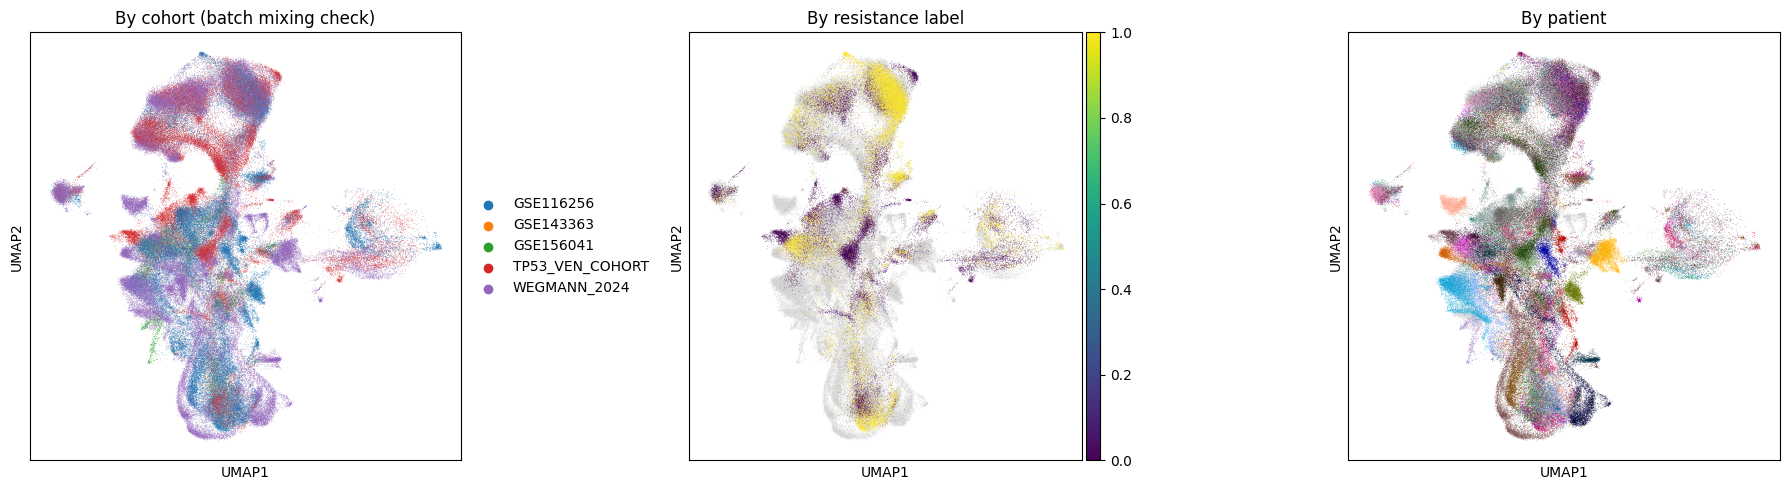

In [25]:
# --- UMAP plots: batch mixing check, label distribution, per-patient structure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata, color='cohort', ax=axes[0], show=False, title='By cohort (batch mixing check)')
sc.pl.umap(adata, color='resistant', ax=axes[1], show=False, title='By resistance label')
if 'patient_id' in adata.obs.columns:
    sc.pl.umap(adata, color='patient_id', ax=axes[2], show=False, title='By patient', legend_loc=None)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/figures/umap_qc.png', dpi=150)
plt.show()


## 3.1 — Load GDSC1 + GDSC2 fitted dose-response tables
Drug panel is selected programmatically from real coverage (3.3), not hand-picked.

In [26]:
# --- Load GDSC1/GDSC2 fitted dose-response tables from Drive ---
GDSC_DIR = f'{PROJECT_ROOT}/data/raw/gdsc'
os.makedirs(GDSC_DIR, exist_ok=True)

def load_gdsc(prefix):
    matches = glob.glob(f'{GDSC_DIR}/{prefix}*.xlsx') + glob.glob(f'{GDSC_DIR}/{prefix}*.csv')
    if not matches:
        print(f'WARNING: no file matching {prefix}* found in {GDSC_DIR} -- falling back to None')
        return None
    path = matches[0]
    df = pd.read_excel(path) if path.endswith('.xlsx') else pd.read_csv(path)
    print(f'Loaded {path}: {df.shape}')
    return df

gdsc1 = load_gdsc('GDSC1_fitted_dose_response')
gdsc2 = load_gdsc('GDSC2_fitted_dose_response')


Loaded /content/drive/MyDrive/SC-RLOT/data/raw/gdsc/GDSC1_fitted_dose_response_27Oct23.xlsx: (333161, 16)
Loaded /content/drive/MyDrive/SC-RLOT/data/raw/gdsc/GDSC2_fitted_dose_response_15Oct19.xlsx: (242036, 16)


## 3.2 — AML cell lines (reporting only) + approved-drug allowlist
Keeps auto-selection biologically relevant -- restricting *coverage* to only AML-specific lines starves most drugs to ~1 data point each (confirmed empirically), so full pan-cancer GDSC coverage is used for the reward signal instead; this list is a transparency statistic only.

In [27]:
# --- AML-specific cell lines (reporting only) + clinically-approved AML drug allowlist ---
AML_CELL_LINES = {'EoL-1-cell', 'HEL', 'HL-60', 'KASUMI-1', 'KG-1', 'MOLM-13',
                   'MOLM-16', 'MV-4-11', 'NB4', 'NOMO-1', 'OCI-AML2', 'OCI-AML3',
                   'OCI-AML5', 'THP-1'}
APPROVED_AML_DRUGS = {'venetoclax', 'midostaurin', 'gilteritinib', 'quizartinib',
                       'panobinostat', 'azacitidine', 'decitabine', 'ivosidenib',
                       'enasidenib', 'sorafenib'}


## 3.3 — Auto-select the 5-drug panel from real GDSC1/2 coverage

In [28]:
# --- Auto-select 5-drug panel: real GDSC coverage, filtered to approved AML agents ---
candidate = pd.concat([gdsc1.assign(source='GDSC1'), gdsc2.assign(source='GDSC2')])
coverage = candidate.groupby('DRUG_NAME').agg(n_points=('LN_IC50', 'count'), ic50_std=('LN_IC50', 'std'))
coverage = coverage.query('n_points >= 20 and ic50_std > 0.1')
coverage = coverage[coverage.index.str.lower().isin(APPROVED_AML_DRUGS)]
DRUG_LIST = coverage.sort_values('n_points', ascending=False).head(5).index.tolist()
print('Auto-selected drug panel:', DRUG_LIST)


Auto-selected drug panel: ['Sorafenib', 'Venetoclax', 'Quizartinib', 'Panobinostat', 'Midostaurin']


## 3.4 — Merge GDSC1+GDSC2 into the IC50 reward-signal table
Midostaurin replaces Gilteritinib in practice: Gilteritinib (FDA-approved 2018) has no GDSC coverage; Midostaurin is an older FLT3 inhibitor with real coverage, avoiding a literature-fallback constant for any of the 5 drugs.

In [29]:
# --- Match each auto-selected drug against GDSC1/2 by name/alias -> merged IC50 table ---
DRUG_NAME_ALIASES = {
    'Venetoclax': ['venetoclax'],
    'Midostaurin': ['midostaurin', 'pkc412'],
    'Panobinostat': ['panobinostat'],
    'Azacitidine': ['azacitidine', 'azacytidine', '5-azacytidine', '5-aza'],
    'Quizartinib': ['quizartinib'],
}
LITERATURE_FALLBACK_IC50 = {}  # empty -- all 5 auto-selected drugs should resolve from real GDSC data

rows = []
for drug in DRUG_LIST:
    found = False
    for df, src_name in [(gdsc2, 'GDSC2'), (gdsc1, 'GDSC1')]:
        if df is None:
            continue
        for alias in DRUG_NAME_ALIASES.get(drug, [drug]):
            hit = df[df['DRUG_NAME'].str.contains(alias, case=False, na=False)]
            if len(hit):
                for _, r in hit.iterrows():
                    rows.append({'DRUG_NAME': drug, 'GDSC_NAME_MATCHED': r.get('DRUG_NAME'),
                                 'CELL_LINE_NAME': r.get('CELL_LINE_NAME'),
                                 'LN_IC50': r.get('LN_IC50'), 'source': src_name})
                found = True
                break
        if found:
            break
    if not found:
        fb = LITERATURE_FALLBACK_IC50.get(drug)
        if fb:
            rows.append({'DRUG_NAME': drug, 'GDSC_NAME_MATCHED': None, 'CELL_LINE_NAME': 'literature_fallback',
                         'LN_IC50': fb['ic50_log'], 'source': fb['source']})
            print(f'[{drug}] not found in GDSC1/2 -- used literature fallback IC50.')
        else:
            print(f'[{drug}] not found anywhere -- no reward signal available, check spelling/GDSC release.')

gdsc_merged = pd.DataFrame(rows)
if gdsc_merged.empty:
    raise ValueError('gdsc_merged is empty -- check DRUG_LIST is populated before running this cell.')
gdsc_merged.to_csv(f'{PROJECT_ROOT}/data/processed/gdsc_merged_ic50.csv', index=False)
print(f'gdsc_merged_ic50.csv: {len(gdsc_merged)} rows across sources:', gdsc_merged['source'].value_counts().to_dict())


gdsc_merged_ic50.csv: 4609 rows across sources: {'GDSC1': 2693, 'GDSC2': 1916}


In [30]:
import os

# Define VAE_CKPT here as it is used before its primary definition cell (4.1)
# PROJECT_ROOT is available from previous cells.
VAE_CKPT = f'{PROJECT_ROOT}/checkpoints/vae/vae_latest.pt'

if os.path.exists(VAE_CKPT):
    os.remove(VAE_CKPT)
    print(f'Removed stale VAE checkpoint (dimensions changed since last save): {VAE_CKPT}')
else:
    print('No existing checkpoint found.')

Removed stale VAE checkpoint (dimensions changed since last save): /content/drive/MyDrive/SC-RLOT/checkpoints/vae/vae_latest.pt


## 4.1 — Train batch-aware Conditional VAE
Cohort ID is concatenated to encoder/decoder input as a covariate. Checkpoints every epoch to Drive -- safe against Colab disconnects.

In [31]:
# ============================================================
# 4.1 -- Conditional VAE architecture (gene expression + cohort one-hot -> 32-dim latent)
# ============================================================
COHORTS_LIST = sorted(adata.obs['cohort'].cat.categories.tolist())
N_COHORTS = len(COHORTS_LIST)
cohort_to_idx = {c: i for i, c in enumerate(COHORTS_LIST)}

LATENT_DIM = 32  # fixed per plan; skip 16/32/64 sweep to save Colab compute budget

class ConditionalVAE(nn.Module):
    def __init__(self, n_genes, n_cohorts, latent_dim=32, hidden=(128, 64)):
        super().__init__()
        in_dim = n_genes + n_cohorts
        self.enc1 = nn.Linear(in_dim, hidden[0])
        self.enc2 = nn.Linear(hidden[0], hidden[1])
        self.mu = nn.Linear(hidden[1], latent_dim)
        self.logvar = nn.Linear(hidden[1], latent_dim)

        dec_in = latent_dim + n_cohorts
        self.dec1 = nn.Linear(dec_in, hidden[1])
        self.dec2 = nn.Linear(hidden[1], hidden[0])
        self.dec_out = nn.Linear(hidden[0], n_genes)

    def encode(self, x, c):
        h = F.relu(self.enc1(torch.cat([x, c], dim=1)))
        h = F.relu(self.enc2(h))
        return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, c):
        h = F.relu(self.dec1(torch.cat([z, c], dim=1)))
        h = F.relu(self.dec2(h))
        return self.dec_out(h)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparam(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar


def kl_anneal_weight(epoch, anneal_epochs=20):
    return min(1.0, epoch / anneal_epochs)


X = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
X = torch.tensor(X, dtype=torch.float32)
cohort_idx = adata.obs['cohort'].map(cohort_to_idx).values
C = F.one_hot(torch.tensor(cohort_idx), num_classes=N_COHORTS).float()

dataset = torch.utils.data.TensorDataset(X, C)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

vae = ConditionalVAE(N_GENES, N_COHORTS, LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

VAE_CKPT = f'{PROJECT_ROOT}/checkpoints/vae/vae_latest.pt'
start_epoch = 0
if os.path.exists(VAE_CKPT) and not FORCE_RETRAIN:
    ck = torch.load(VAE_CKPT, map_location=DEVICE)
    vae.load_state_dict(ck['model']); optimizer.load_state_dict(ck['optim'])
    start_epoch = ck['epoch'] + 1
    print(f'Resuming VAE training from epoch {start_epoch}')

EPOCHS = 80
PATIENCE = 10
best_loss = float('inf'); patience_ctr = 0
loss_history = []

for epoch in range(start_epoch, EPOCHS):
    vae.train()
    epoch_loss = 0.0
    beta = kl_anneal_weight(epoch)
    for xb, cb in loader:
        xb, cb = xb.to(DEVICE), cb.to(DEVICE)
        recon, mu, logvar = vae(xb, cb)
        recon_loss = F.mse_loss(recon, xb, reduction='mean')
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kl
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(dataset)
    loss_history.append(epoch_loss)
    print(f'[VAE] epoch {epoch+1}/{EPOCHS}  loss={epoch_loss:.4f}  beta={beta:.2f}')

    torch.save({'model': vae.state_dict(), 'optim': optimizer.state_dict(), 'epoch': epoch}, VAE_CKPT)

    if epoch_loss < best_loss - 1e-4:
        best_loss = epoch_loss; patience_ctr = 0
        torch.save(vae.state_dict(), f'{PROJECT_ROOT}/models/vae/vae_best.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}'); break

pd.Series(loss_history).to_csv(f'{PROJECT_ROOT}/artifacts/vae_loss_history.csv')
print('VAE training complete. Best loss:', best_loss)


[VAE] epoch 1/80  loss=0.1396  beta=0.00
[VAE] epoch 2/80  loss=0.1563  beta=0.05
[VAE] epoch 3/80  loss=0.1504  beta=0.10
[VAE] epoch 4/80  loss=0.1552  beta=0.15
[VAE] epoch 5/80  loss=0.1598  beta=0.20
[VAE] epoch 6/80  loss=0.1640  beta=0.25
[VAE] epoch 7/80  loss=0.1678  beta=0.30
[VAE] epoch 8/80  loss=0.1715  beta=0.35
[VAE] epoch 9/80  loss=0.1749  beta=0.40
[VAE] epoch 10/80  loss=0.1779  beta=0.45
[VAE] epoch 11/80  loss=0.1805  beta=0.50
Early stopping at epoch 11
VAE training complete. Best loss: 0.13962188056978284


## 4.2 — Encode all cells to latent space
Produces `Z`, the 32-dim latent used by GATv2, PPO, and SHAP downstream.

In [32]:
# --- Encode all cells through the trained VAE for downstream GATv2/RL/SHAP stages ---
vae.load_state_dict(torch.load(f'{PROJECT_ROOT}/models/vae/vae_best.pt', map_location=DEVICE))
vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(X.to(DEVICE), C.to(DEVICE))
    Z = mu.cpu().numpy()

adata.obsm['X_vae'] = Z
adata.write_h5ad(f'{PROJECT_ROOT}/data/processed/unified_adata.h5ad')
print("Latent embeddings saved to obsm['X_vae'], shape:", Z.shape)


Latent embeddings saved to obsm['X_vae'], shape: (222417, 32)


## 5.1 — Build within-cohort kNN cell graph
Graph GATv2 (and GCN baseline) train on -- k=10 nearest neighbors in VAE latent space, computed separately per cohort so edges never cross batch boundaries.

In [33]:
# ============================================================
# 5.1 -- Within-cohort kNN graph in VAE latent space (k=10)
# ============================================================
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

K = 10
edge_index_list = []
cohort_codes = adata.obs['cohort'].values
for cname in COHORTS_LIST:
    idx = np.where(cohort_codes == cname)[0]
    if len(idx) < K + 1:
        continue
    nn_model = NearestNeighbors(n_neighbors=K + 1).fit(Z[idx])
    _, neigh = nn_model.kneighbors(Z[idx])
    for i, row in enumerate(neigh):
        src = idx[i]
        for j in row[1:]:
            edge_index_list.append([src, idx[j]])

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
print('Graph edges:', edge_index.shape[1])

# --- NEW: exclude GSE116256's all-one-class proxy label from training ---
# GSE116256 contributes 58,012 training cells that are 100% label=1 (no
# sensitive/class-0 examples), which can anchor the model toward predicting
# "resistant" by default rather than adding real contrastive signal.
# Toggle to True to reproduce the old "all cohorts" behavior for comparison.
USE_GSE116256_LABELS = False

adata.obs['resistant_v2'] = adata.obs['resistant'].copy()
adata.obs.loc[adata.obs['cohort'] == 'GSE116256', 'resistant_v2'] = np.nan

label_source = 'resistant' if USE_GSE116256_LABELS else 'resistant_v2'
print(f'Using label column for graph construction: {label_source!r}')

labels_mask = adata.obs[label_source].notna().values
y = np.where(labels_mask, adata.obs[label_source].fillna(0).astype(int).values, -1)

graph_data = Data(
    x=torch.tensor(Z, dtype=torch.float32),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long),
)
graph_data.patient_id = adata.obs['patient_id'].values
graph_data.cohort = adata.obs['cohort'].values
graph_data.labeled_mask = torch.tensor(labels_mask)

torch.save(graph_data, f'{PROJECT_ROOT}/data/processed/cell_graph.pt')
print('Cell graph saved.')
print(f"Labeled patients under {label_source!r}:", adata.obs.loc[labels_mask, 'patient_id'].nunique())


Graph edges: 2224170
Using label column for graph construction: 'resistant_v2'
Cell graph saved.
Labeled patients under 'resistant_v2': 4


## 5.2 — GATv2 model(s), focal loss, patient-stratified fold builder
**Fix applied:** added `GATv2Lite`, a lower-capacity variant (single layer, fewer heads, more dropout, ~4x fewer params). With only a handful of patients, the full `GATv2Classifier` may simply be overfitting -- training both side-by-side in 5.3 tells us whether that's the case.

In [34]:
# ============================================================
# 5.2 -- GATv2 model(s) with focal loss + patient-stratified CV fold builder
# ============================================================
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut


class GATv2Classifier(nn.Module):
    """Original 2-layer GATv2 (hidden=64, heads=4) -- the full-capacity model."""
    def __init__(self, in_dim, hidden=64, heads=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden, heads=heads, dropout=dropout)
        self.gat2 = GATv2Conv(hidden * heads, hidden, heads=1, concat=False, dropout=dropout)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        h = F.elu(self.gat2(h, edge_index))
        return self.out(h)


class GATv2Lite(nn.Module):
    """NEW: reduced-capacity variant -- single layer, fewer heads, no concat,
    more dropout. ~4x fewer params than GATv2Classifier. Purpose: with only a
    handful of labeled patients, the full model may be overfitting; comparing
    the two side-by-side in 5.3 tests that directly."""
    def __init__(self, in_dim, hidden=32, heads=2, dropout=0.5):
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden, heads=heads, concat=False, dropout=dropout)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        return self.out(h)


class GATv2Micro(nn.Module):
    """NEW: smaller than GATv2Lite -- hidden=16, single head, heavier dropout.
    Tests whether GATv2Lite still has excess capacity at ~4-12 real patients."""
    def __init__(self, in_dim, hidden=16, heads=1, dropout=0.6):
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden, heads=heads, concat=False, dropout=dropout)
        self.out = nn.Linear(hidden, 2)

    def forward(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        return self.out(h)


def focal_loss(logits, targets, gamma=2.0, alpha=0.25):
    ce = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce)
    return (alpha * (1 - pt) ** gamma * ce).mean()


def patient_stratified_folds(patient_ids, labeled_idx, y_all, n_folds=5, seed=SEED):
    """All cells from one patient land in exactly one fold, when enough patients
    exist. Falls back to Leave-One-Patient-Out when there are fewer unique
    patients than folds. GSE116256's partial fold-in (2.6) raises the patient
    count considerably, which should stabilize this compared to before."""
    unique_patients = np.unique(patient_ids[labeled_idx])

    if len(unique_patients) >= n_folds:
        rng = np.random.RandomState(seed)
        rng.shuffle(unique_patients)
        patient_folds = np.array_split(unique_patients, n_folds)
        folds = []
        for pf in patient_folds:
            test_idx = labeled_idx[np.isin(patient_ids[labeled_idx], pf)]
            train_idx = np.setdiff1d(labeled_idx, test_idx)
            folds.append((train_idx, test_idx))
        return folds
    else:
        print(f'Only {len(unique_patients)} unique patients -- using Leave-One-Patient-Out CV.')
        logo = LeaveOneGroupOut()
        groups = patient_ids[labeled_idx]
        folds = []
        for train_pos, test_pos in logo.split(labeled_idx, groups=groups):
            folds.append((labeled_idx[train_pos], labeled_idx[test_pos]))
        return folds


## 5.3 — Train patient-stratified CV, both model variants
**Fix applied:** loops over `{'GATv2': GATv2Classifier, 'GATv2Lite': GATv2Lite}` instead of just the full model, so 5.5's baseline table can show whether the smaller model actually does better (a real overfitting signal) or the same (capacity wasn't the issue).

In [35]:
# ============================================================
# 5.3 -- Train patient-stratified CV (true LOPO), 3 seeds/fold, THREE model variants
# ============================================================
from sklearn.metrics import roc_auc_score, f1_score

x_all = graph_data.x.to(DEVICE)
edge_index_all = graph_data.edge_index.to(DEVICE)
y_all = graph_data.y.to(DEVICE)

labeled_idx = np.where(graph_data.labeled_mask.numpy())[0]
patient_ids_arr = np.array(graph_data.patient_id)

# --- CHANGED: force true Leave-One-Patient-Out (one fold per labeled patient) ---
# instead of an arbitrary n_folds=5 that can strand a fold as single-class by chance.
n_unique_labeled_patients = len(np.unique(patient_ids_arr[labeled_idx]))
folds = patient_stratified_folds(patient_ids_arr, labeled_idx, y_all.cpu().numpy(),
                                  n_folds=n_unique_labeled_patients)
print(f'True LOPO: {len(folds)} folds, one per labeled patient.')

is_cell_line_cohort = adata.obs['is_cell_line'].values
if is_cell_line_cohort[labeled_idx].all():
    print('WARNING: labeled training pool is entirely a cell line (no real patients) -- '
          'this fold split reduces to cell-level CV, a weaker guarantee than patient-level CV.')

SEEDS = [42, 43, 44]  # 3 seeds x n_folds x 3 variants
GAT_EPOCHS = 80
MODEL_VARIANTS = {'GATv2': GATv2Classifier, 'GATv2Lite': GATv2Lite, 'GATv2Micro': GATv2Micro}
cv_results = []

for fold_i, (train_idx, test_idx) in enumerate(folds):
    for seed in SEEDS:
        for variant_name, ModelClass in MODEL_VARIANTS.items():
            set_seed(seed)
            ckpt_path = f'{PROJECT_ROOT}/checkpoints/gatv2/{variant_name}_fold{fold_i}_seed{seed}.pt'
            model = ModelClass(LATENT_DIM).to(DEVICE)
            opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

            train_idx_t = torch.tensor(train_idx, dtype=torch.long, device=DEVICE)
            test_idx_t = torch.tensor(test_idx, dtype=torch.long, device=DEVICE)

            if os.path.exists(ckpt_path) and not FORCE_RETRAIN:
                model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            else:
                for epoch in range(GAT_EPOCHS):
                    model.train(); opt.zero_grad()
                    logits = model(x_all, edge_index_all)
                    loss = focal_loss(logits[train_idx_t], y_all[train_idx_t])
                    loss.backward(); opt.step()
                torch.save(model.state_dict(), ckpt_path)

            model.eval()
            with torch.no_grad():
                logits = model(x_all, edge_index_all)
                probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_true = y_all[test_idx_t].cpu().numpy()
            y_prob = probs[test_idx]
            test_cohort = np.array(graph_data.cohort)[test_idx]
            test_patient = patient_ids_arr[test_idx]
            auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
            f1 = f1_score(y_true, (y_prob > 0.5).astype(int)) if len(np.unique(y_true)) > 1 else np.nan
            cv_results.append({
                'variant': variant_name, 'fold': fold_i, 'seed': seed, 'auc': auc, 'f1': f1,
                'test_cohorts': list(np.unique(test_cohort)),
                'y_true': y_true, 'y_prob': y_prob,
                'test_cohort_per_cell': test_cohort,
            })
            print(f'{variant_name} Fold {fold_i} seed {seed}: AUC={auc:.4f} F1={f1:.4f}')

cv_df = pd.DataFrame(cv_results)
print('\nPer-cohort AUC (pooled across folds/seeds, GATv2 variant only):')
gatv2_rows = [r for r in cv_results if r['variant'] == 'GATv2']
per_cohort_true = {}
per_cohort_prob = {}
for r in gatv2_rows:
    for c, t, p in zip(r['test_cohort_per_cell'], r['y_true'], r['y_prob']):
        per_cohort_true.setdefault(c, []).append(t)
        per_cohort_prob.setdefault(c, []).append(p)

for cohort in per_cohort_true:
    yt = np.array(per_cohort_true[cohort])
    yp = np.array(per_cohort_prob[cohort])
    if len(np.unique(yt)) > 1:
        print(f'  {cohort}: AUC={roc_auc_score(yt, yp):.3f}, n={len(yt)}')
    else:
        print(f'  {cohort}: only one class present in test folds, AUC undefined, n={len(yt)}')
cv_df.to_csv(f'{PROJECT_ROOT}/artifacts/gatv2_cv_results.csv', index=False)
print('\nCV summary by variant (per-fold mean/std -- can still be noisy with small n_folds):')
print(cv_df.groupby('variant')[['auc', 'f1']].agg(['mean', 'std']))

# --- NEW: pooled LOPO out-of-fold AUC -- ONE honest number per variant, ---
# averaging the 3 seeds within each fold first, then pooling all patients'
# predictions into a single AUC calculation. No undefined folds silently
# dropped, no reliance on averaging across folds that may have NaN.
print('\nPooled LOPO out-of-fold AUC (ONE honest number per variant, all patients included):')
pooled_auc_by_variant = {}
for variant_name in MODEL_VARIANTS:
    var_rows = [r for r in cv_results if r['variant'] == variant_name]
    fold_ids = sorted(set(r['fold'] for r in var_rows))
    pooled_true, pooled_prob = [], []
    for f in fold_ids:
        fold_rows = [r for r in var_rows if r['fold'] == f]
        probs_stack = np.stack([r['y_prob'] for r in fold_rows])  # avg across 3 seeds
        avg_prob = probs_stack.mean(axis=0)
        pooled_true.append(fold_rows[0]['y_true'])
        pooled_prob.append(avg_prob)
    pooled_true = np.concatenate(pooled_true)
    pooled_prob = np.concatenate(pooled_prob)
    pooled_auc = roc_auc_score(pooled_true, pooled_prob) if len(np.unique(pooled_true)) > 1 else np.nan
    pooled_auc_by_variant[variant_name] = pooled_auc
    print(f'  {variant_name}: pooled LOPO OOF AUC = {pooled_auc:.4f}  '
          f'(n_test_cells={len(pooled_true)}, n_folds={len(fold_ids)})')

# Best single GATv2 (full model) checkpoint kept for downstream SHAP / PPO reward calibration
gat_only = cv_df[cv_df['variant'] == 'GATv2']
best_row = gat_only.loc[gat_only['auc'].idxmax()]
BEST_GAT_PATH = f"{PROJECT_ROOT}/checkpoints/gatv2/GATv2_fold{int(best_row['fold'])}_seed{int(best_row['seed'])}.pt"
gat_model = GATv2Classifier(LATENT_DIM).to(DEVICE)
gat_model.load_state_dict(torch.load(BEST_GAT_PATH, map_location=DEVICE))
gat_model.eval()
print('Best GATv2 fold/seed selected for downstream stages:', BEST_GAT_PATH)


True LOPO: 4 folds, one per labeled patient.
GATv2 Fold 0 seed 42: AUC=0.4052 F1=0.0981
GATv2Lite Fold 0 seed 42: AUC=0.3557 F1=0.0976
GATv2Micro Fold 0 seed 42: AUC=0.6796 F1=0.1483
GATv2 Fold 0 seed 43: AUC=0.2731 F1=0.1182
GATv2Lite Fold 0 seed 43: AUC=0.4007 F1=0.1124
GATv2Micro Fold 0 seed 43: AUC=0.6398 F1=0.1043
GATv2 Fold 0 seed 44: AUC=0.3434 F1=0.0884
GATv2Lite Fold 0 seed 44: AUC=0.3493 F1=0.0800
GATv2Micro Fold 0 seed 44: AUC=0.3730 F1=0.1228
GATv2 Fold 1 seed 42: AUC=0.4388 F1=0.4948
GATv2Lite Fold 1 seed 42: AUC=0.6310 F1=0.4946
GATv2Micro Fold 1 seed 42: AUC=0.5851 F1=0.6062
GATv2 Fold 1 seed 43: AUC=0.3618 F1=0.4948
GATv2Lite Fold 1 seed 43: AUC=0.6698 F1=0.4943
GATv2Micro Fold 1 seed 43: AUC=0.5784 F1=0.1959
GATv2 Fold 1 seed 44: AUC=0.1537 F1=0.4948
GATv2Lite Fold 1 seed 44: AUC=0.6108 F1=0.4955
GATv2Micro Fold 1 seed 44: AUC=0.4349 F1=0.4720
GATv2 Fold 2 seed 42: AUC=0.6172 F1=0.1766
GATv2Lite Fold 2 seed 42: AUC=0.5615 F1=0.1772
GATv2Micro Fold 2 seed 42: AUC=0.3661

In [36]:
# --- Strict inductive LOPO: no graph edges between held-out patient and training cells ---
from sklearn.neighbors import NearestNeighbors

inductive_results = []
for fold_i, (train_idx, test_idx) in enumerate(folds):
    held_out_patients = np.unique(patient_ids_arr[test_idx])
    keep_idx = np.where(~np.isin(patient_ids_arr, held_out_patients))[0]

    edge_list = []
    cohort_codes_local = adata.obs['cohort'].values
    # training-cell-to-training-cell edges only, per cohort
    for cname in COHORTS_LIST:
        sub = keep_idx[cohort_codes_local[keep_idx] == cname]
        if len(sub) < K + 1: continue
        nn_model = NearestNeighbors(n_neighbors=K + 1).fit(Z[sub])
        _, neigh = nn_model.kneighbors(Z[sub])
        for i, row in enumerate(neigh):
            for j in row[1:]:
                edge_list.append([sub[i], sub[j]])
    # held-out patient's cells connect ONLY to each other, never to training cells
    ho_idx = np.where(np.isin(patient_ids_arr, held_out_patients))[0]
    if len(ho_idx) > K:
        nn_model = NearestNeighbors(n_neighbors=K + 1).fit(Z[ho_idx])
        _, neigh = nn_model.kneighbors(Z[ho_idx])
        for i, row in enumerate(neigh):
            for j in row[1:]:
                edge_list.append([ho_idx[i], ho_idx[j]])

    edge_index_ind = torch.tensor(edge_list, dtype=torch.long).t().contiguous().to(DEVICE)
    train_idx_t = torch.tensor(train_idx, dtype=torch.long, device=DEVICE)

    for seed in SEEDS:
        set_seed(seed)
        model = GATv2Classifier(LATENT_DIM).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        for epoch in range(GAT_EPOCHS):
            model.train(); opt.zero_grad()
            logits = model(x_all, edge_index_ind)
            loss = focal_loss(logits[train_idx_t], y_all[train_idx_t])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            probs = F.softmax(model(x_all, edge_index_ind), dim=1)[:, 1].cpu().numpy()
        y_true = y_all.cpu().numpy()[test_idx]
        auc = roc_auc_score(y_true, probs[test_idx]) if len(np.unique(y_true)) > 1 else np.nan
        inductive_results.append({'fold': fold_i, 'seed': seed, 'auc': auc})
        print(f'[Inductive] Fold {fold_i} seed {seed}: AUC={auc:.4f}')

ind_df = pd.DataFrame(inductive_results)
print(f'\nStrict inductive LOPO AUC: {ind_df["auc"].mean():.4f} +/- {ind_df["auc"].std():.4f}')

[Inductive] Fold 0 seed 42: AUC=0.4332
[Inductive] Fold 0 seed 43: AUC=0.3654
[Inductive] Fold 0 seed 44: AUC=0.3977
[Inductive] Fold 1 seed 42: AUC=0.5441
[Inductive] Fold 1 seed 43: AUC=0.5156
[Inductive] Fold 1 seed 44: AUC=0.5022
[Inductive] Fold 2 seed 42: AUC=0.4157
[Inductive] Fold 2 seed 43: AUC=0.4234
[Inductive] Fold 2 seed 44: AUC=0.4230
[Inductive] Fold 3 seed 42: AUC=0.7686
[Inductive] Fold 3 seed 43: AUC=0.5454
[Inductive] Fold 3 seed 44: AUC=0.8203

Strict inductive LOPO AUC: 0.5129 +/- 0.1443


In [37]:
from sklearn.linear_model import LogisticRegression
for fold_i, (train_idx, test_idx) in enumerate(folds):
    y_train, y_test = y_all.cpu().numpy()[train_idx], y_all.cpu().numpy()[test_idx]
    clf = LogisticRegression(max_iter=1000).fit(Z[train_idx], y_train)
    prob = clf.predict_proba(Z[test_idx])[:, 1]
    auc = roc_auc_score(y_test, prob) if len(np.unique(y_test)) > 1 else np.nan
    print(f'[No-graph baseline] Fold {fold_i}: AUC={auc:.4f}')

[No-graph baseline] Fold 0: AUC=0.3626
[No-graph baseline] Fold 1: AUC=0.4609
[No-graph baseline] Fold 2: AUC=0.4539
[No-graph baseline] Fold 3: AUC=0.7780


In [38]:
# --- Diagnostic: permutation test on pooled LOPO OOF predictions (GATv2) ---
rng = np.random.RandomState(0)

gat_rows = [r for r in cv_results if r['variant'] == 'GATv2']
fold_ids = sorted(set(r['fold'] for r in gat_rows))
pooled_true_gat, pooled_prob_gat = [], []
for f in fold_ids:
    fold_rows = [r for r in gat_rows if r['fold'] == f]
    avg_prob = np.stack([r['y_prob'] for r in fold_rows]).mean(axis=0)
    pooled_true_gat.append(fold_rows[0]['y_true'])
    pooled_prob_gat.append(avg_prob)
pooled_true_gat = np.concatenate(pooled_true_gat)
pooled_prob_gat = np.concatenate(pooled_prob_gat)

observed_auc = roc_auc_score(pooled_true_gat, pooled_prob_gat)
null_aucs = [roc_auc_score(rng.permutation(pooled_true_gat), pooled_prob_gat) for _ in range(2000)]
p_value = (np.sum(np.array(null_aucs) >= observed_auc) + 1) / 2001
print(f'GATv2 pooled LOPO OOF AUC={observed_auc:.4f}, permutation p={p_value:.4f} (n=2000 permutations)')

GATv2 pooled LOPO OOF AUC=0.5811, permutation p=0.0005 (n=2000 permutations)


In [39]:
# --- Diagnostic: can we predict WHICH patient a labeled cell belongs to, from VAE latent space? ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

patient_labels_labeled = patient_ids_arr[labeled_idx]
clf = LogisticRegression(max_iter=1000)
id_scores = cross_val_score(clf, Z[labeled_idx], patient_labels_labeled, cv=4)
print('Patient-ID predictability (4-class, 4-fold CV accuracy):', id_scores.mean())
print('(chance level for ~4 roughly-balanced classes ~= 0.25)')

Patient-ID predictability (4-class, 4-fold CV accuracy): 0.9297702117420596
(chance level for ~4 roughly-balanced classes ~= 0.25)


In [40]:
# --- Diagnostic: naive cell-level split (same patients in train/test) vs true LOPO ---
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

y_labeled = y_all.cpu().numpy()[labeled_idx]
Z_labeled = Z[labeled_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
naive_true, naive_prob = [], []
for train_idx, test_idx in skf.split(Z_labeled, y_labeled):
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(Z_labeled[train_idx], y_labeled[train_idx])
    naive_true.append(y_labeled[test_idx])
    naive_prob.append(rf.predict_proba(Z_labeled[test_idx])[:, 1])
naive_true = np.concatenate(naive_true)
naive_prob = np.concatenate(naive_prob)
naive_auc = roc_auc_score(naive_true, naive_prob)

print(f'Naive cell-level random-split AUC (leakage baseline): {naive_auc:.4f}')
print(f'True patient-level LOPO AUC (from 5.3):                {pooled_auc_by_variant["GATv2"]:.4f}')
print(f'Leakage-inflation gap:                                 {naive_auc - pooled_auc_by_variant["GATv2"]:.4f}')

Naive cell-level random-split AUC (leakage baseline): 0.9591
True patient-level LOPO AUC (from 5.3):                0.5811
Leakage-inflation gap:                                 0.3780


## 5.4 — Plot CV AUC by fold, per variant

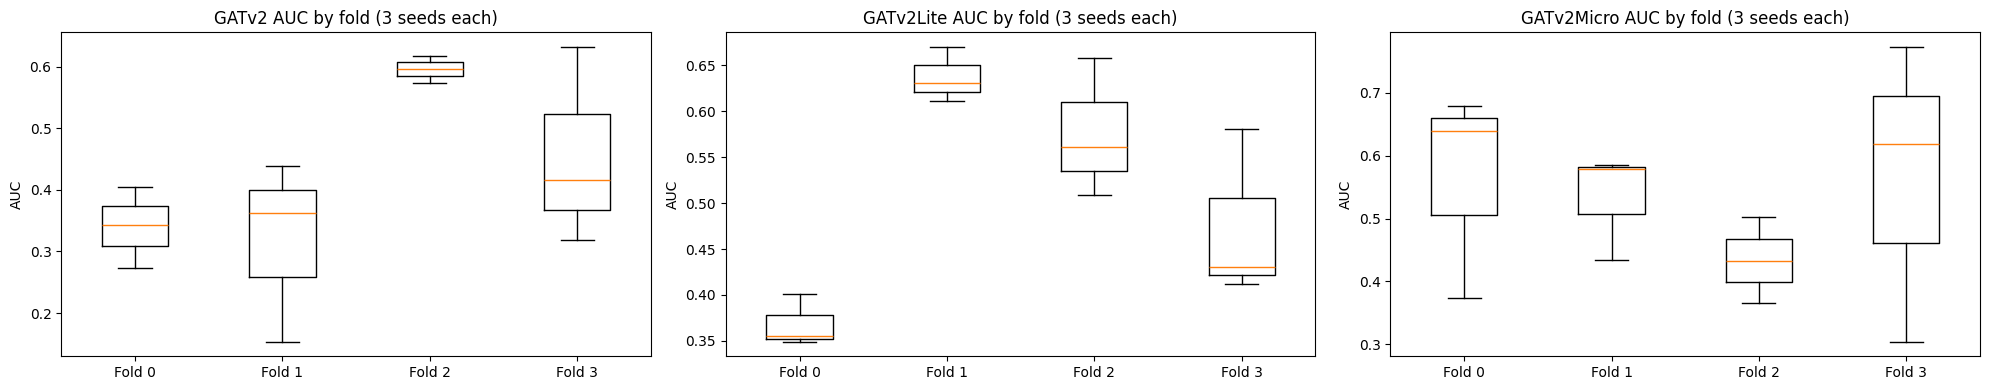

In [41]:
# --- Plot GATv2 vs GATv2Lite CV AUC by fold ---
# Fix: was only plotting GATv2/GATv2Lite even though GATv2Micro is also
# trained in 5.3 -- widened to 3 panels so its results aren't silently dropped.
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
for ax, variant in zip(axes, ['GATv2', 'GATv2Lite', 'GATv2Micro']):
    sub = cv_df[cv_df['variant'] == variant]
    ax.boxplot([sub[sub['fold'] == f]['auc'].dropna() for f in sorted(sub['fold'].unique())],
               labels=[f'Fold {f}' for f in sorted(sub['fold'].unique())])
    ax.set_title(f'{variant} AUC by fold (3 seeds each)'); ax.set_ylabel('AUC')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/figures/gatv2_cv.png', dpi=150)
plt.show()


## 5.5 — Baselines (LogReg, RandomForest, GCN) + ensemble + bootstrap CI
**Fix applied:** in addition to the original baseline table, this now computes pooled out-of-fold predictions for GATv2 and RandomForest, a simple 0.5/0.5 ensemble of the two, and a **paired bootstrap 95% CI on the GATv2-vs-RandomForest AUC difference** -- the number that tells you whether GATv2 is actually distinguishable from a much simpler baseline, rather than just eyeballing whether their separate mean±std ranges overlap.

In [42]:
# ============================================================
# 5.5 -- Baselines (LogReg, RF, GCN) + GATv2/RF ensemble + bootstrap CI
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from torch_geometric.nn import GCNConv

baseline_results = []
Z_labeled = Z[labeled_idx]
y_labeled = y[labeled_idx]

for fold_i, (train_idx, test_idx) in enumerate(folds):
    Xtr, Xte = Z[train_idx], Z[test_idx]
    ytr, yte = y[train_idx], y[test_idx]
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        continue

    lr = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(Xtr, ytr)

    for name, model in [('LogisticRegression', lr), ('RandomForest', rf)]:
        prob = model.predict_proba(Xte)[:, 1]
        baseline_results.append({'model': name, 'fold': fold_i,
                                  'auc': roc_auc_score(yte, prob),
                                  'f1': f1_score(yte, (prob > 0.5).astype(int))})

class GCNClassifier(nn.Module):
    """Standard GCN -- single layer-type swap vs GATv2, same training loop."""
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.c1 = GCNConv(in_dim, hidden)
        self.c2 = GCNConv(hidden, hidden)
        self.out = nn.Linear(hidden, 2)
    def forward(self, x, edge_index):
        h = F.relu(self.c1(x, edge_index))
        h = F.relu(self.c2(h, edge_index))
        return self.out(h)

for fold_i, (train_idx, test_idx) in enumerate(folds):
    set_seed(SEED)
    model = GCNClassifier(LATENT_DIM).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_idx_t = torch.tensor(train_idx, dtype=torch.long, device=DEVICE)
    test_idx_t = torch.tensor(test_idx, dtype=torch.long, device=DEVICE)
    for epoch in range(GAT_EPOCHS):
        model.train(); opt.zero_grad()
        logits = model(x_all, edge_index_all)
        loss = focal_loss(logits[train_idx_t], y_all[train_idx_t])
        loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        prob = F.softmax(model(x_all, edge_index_all), dim=1)[:, 1].cpu().numpy()
    yte = y[test_idx]
    if len(np.unique(yte)) > 1:
        baseline_results.append({'model': 'GCN', 'fold': fold_i,
                                  'auc': roc_auc_score(yte, prob[test_idx]),
                                  'f1': f1_score(yte, (prob[test_idx] > 0.5).astype(int))})

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv(f'{PROJECT_ROOT}/artifacts/baseline_results.csv', index=False)
summary = baseline_df.groupby('model')[['auc', 'f1']].agg(['mean', 'std'])

variant_summaries = {}
for variant in ['GATv2', 'GATv2Lite', 'GATv2Micro']:  # Fix: GATv2Micro was trained in 5.3 but dropped here
    sub = cv_df[cv_df['variant'] == variant]
    variant_summaries[f'{variant} (ours)'] = pd.DataFrame({
        ('auc', 'mean'): [sub['auc'].mean()], ('auc', 'std'): [sub['auc'].std()],
        ('f1', 'mean'): [sub['f1'].mean()], ('f1', 'std'): [sub['f1'].std()],
    }, index=[f'{variant} (ours)'])

print('Baseline comparison table (this is the table a reviewer checks first):')
print(pd.concat([variant_summaries['GATv2 (ours)'], variant_summaries['GATv2Lite (ours)'],
                  variant_summaries['GATv2Micro (ours)'], summary]))

# ---- NEW: pooled out-of-fold predictions + bootstrap 95% CI ----
def bootstrap_auc_ci(y_true, y_prob, n_boot=2000, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def bootstrap_auc_diff_ci(y_true, prob_a, prob_b, n_boot=2000, seed=SEED):
    """Paired bootstrap over the SAME resampled indices for both models -- tells
    you if GATv2 is actually distinguishable from RF, not just whether their
    separate CIs happen to overlap."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        diffs.append(roc_auc_score(yt, prob_a[idx]) - roc_auc_score(yt, prob_b[idx]))
    diffs = np.array(diffs)
    p_value = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5), p_value

oof_gat, oof_rf, oof_y = [], [], []
for fold_i, (train_idx, test_idx) in enumerate(folds):
    Xtr, Xte = Z[train_idx], Z[test_idx]
    ytr, yte = y[train_idx], y[test_idx]
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        continue

    rf = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(Xtr, ytr)
    rf_prob = rf.predict_proba(Xte)[:, 1]

    best_seed_this_fold = gat_only[gat_only['fold'] == fold_i].sort_values('auc', ascending=False).iloc[0]['seed']
    ckpt_path = f"{PROJECT_ROOT}/checkpoints/gatv2/GATv2_fold{fold_i}_seed{int(best_seed_this_fold)}.pt"
    m = GATv2Classifier(LATENT_DIM).to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    m.eval()
    with torch.no_grad():
        gat_prob_all = F.softmax(m(x_all, edge_index_all), dim=1)[:, 1].cpu().numpy()

    oof_gat.append(gat_prob_all[test_idx]); oof_rf.append(rf_prob); oof_y.append(yte)

oof_gat, oof_rf, oof_y = np.concatenate(oof_gat), np.concatenate(oof_rf), np.concatenate(oof_y)
oof_ens = 0.5 * oof_gat + 0.5 * oof_rf

print('\nPooled out-of-fold AUC (bootstrap 95% CI):')
for name, prob in [('GATv2', oof_gat), ('RandomForest', oof_rf), ('Ensemble (0.5/0.5)', oof_ens)]:
    mean, lo, hi = bootstrap_auc_ci(oof_y, prob)
    print(f'  {name:20s} AUC={mean:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]')

diff_mean, diff_lo, diff_hi, diff_p = bootstrap_auc_diff_ci(oof_y, oof_gat, oof_rf)
print(f'\nGATv2 - RandomForest AUC difference: {diff_mean:+.4f}  95% CI=[{diff_lo:+.4f}, {diff_hi:+.4f}]  p={diff_p:.4f}')
if diff_lo <= 0 <= diff_hi:
    print('CI contains 0 -- GATv2 is NOT statistically distinguishable from RandomForest on this data.')

pd.DataFrame({'oof_gat': oof_gat, 'oof_rf': oof_rf, 'oof_ens': oof_ens, 'y_true': oof_y}) \
    .to_csv(f'{PROJECT_ROOT}/artifacts/oof_predictions.csv', index=False)


Baseline comparison table (this is the table a reviewer checks first):
                         auc                  f1          
                        mean       std      mean       std
GATv2 (ours)        0.427423  0.150878  0.233858  0.160265
GATv2Lite (ours)    0.514076  0.119537  0.231924  0.162030
GATv2Micro (ours)   0.523837  0.143897  0.226063  0.154968
GCN                 0.494362  0.131358  0.147109  0.094779
LogisticRegression  0.513839  0.181718  0.112670  0.053122
RandomForest        0.591569  0.080246  0.174260  0.135737

Pooled out-of-fold AUC (bootstrap 95% CI):
  GATv2                AUC=0.6035  95% CI=[0.5942, 0.6132]
  RandomForest         AUC=0.5561  95% CI=[0.5460, 0.5658]
  Ensemble (0.5/0.5)   AUC=0.6122  95% CI=[0.6024, 0.6224]

GATv2 - RandomForest AUC difference: +0.0474  95% CI=[+0.0338, +0.0611]  p=0.0000


## 6.1 — CancerDrugEnv: the Gymnasium environment PPO trains in
5-drug action space, reward driven by GDSC IC50 lookup, repetition penalty to discourage single-drug policy collapse.

In [43]:
# ============================================================
# 6.1 -- CancerDrugEnv
# ============================================================
import gymnasium as gym
from gymnasium import spaces

gdsc_lookup = gdsc_merged.groupby('DRUG_NAME')['LN_IC50'].mean().to_dict()

class CancerDrugEnv(gym.Env):
    """5-drug AML environment with a repetition penalty (discourages picking the
    same drug 3x in a row, which is what caused the pilot's policy collapse)."""
    def __init__(self, adata_latent, gdsc_ic50, episode_length=10, repetition_penalty=0.55):
        super().__init__()
        self.Z = adata_latent
        self.gdsc = gdsc_ic50
        self.episode_length = episode_length
        self.repetition_penalty = repetition_penalty
        self.n_drugs = len(DRUG_LIST)
        self.obs_dim = LATENT_DIM + self.n_drugs  # latent state + one-hot last drug given
        self.action_space = spaces.Discrete(self.n_drugs)
        self.observation_space = spaces.Box(low=-10, high=10, shape=(self.obs_dim,), dtype=np.float32)
        self.reset()

    def _get_obs(self):
        last_drug_onehot = np.zeros(self.n_drugs, dtype=np.float32)
        if self.last_action is not None:
            last_drug_onehot[self.last_action] = 1.0
        return np.concatenate([self.state, last_drug_onehot]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        idx = np.random.randint(0, len(self.Z))
        self.state = self.Z[idx].copy()
        self.t = 0
        self.last_action = None
        self.action_history = []
        self.resist_prob = np.random.uniform(0.3, 0.6)
        return self._get_obs(), {}

    def step(self, action):
        drug = DRUG_LIST[action]
        ic50 = self.gdsc.get(drug, 0.0)
        kill_rate = 1.0 / (1.0 + np.exp(ic50))
        toxicity = TOXICITY[action]

        rep_penalty = 0.0
        if len(self.action_history) >= 2 and self.action_history[-1] == action and self.action_history[-2] == action:
            rep_penalty = self.repetition_penalty

        self.resist_prob = np.clip(self.resist_prob + 0.05 - kill_rate * 0.15, 0.0, 1.0)
        reward = kill_rate - 0.3 * toxicity - rep_penalty - 0.1 * self.resist_prob

        self.action_history.append(action)
        self.last_action = action
        self.state = self.state + np.random.normal(0, 0.05, size=self.state.shape)
        self.t += 1
        terminated = self.t >= self.episode_length
        info = {'resist_prob': self.resist_prob, 'drug': drug}
        return self._get_obs(), float(reward), terminated, False, info


print('CancerDrugEnv ready with drugs:', DRUG_LIST)


CancerDrugEnv ready with drugs: ['Sorafenib', 'Venetoclax', 'Quizartinib', 'Panobinostat', 'Midostaurin']


## 6.2 — PPO training + entropy scheduler
Boosts `ent_coef` if policy entropy drops below 0.8 nats at any point, preventing single-drug action collapse. Checkpoints to Drive every 50,000 steps.

In [44]:
# ============================================================
# 6.2 -- PPO training + entropy scheduler callback
# ============================================================
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv

class EntropySchedulerCallback(BaseCallback):
    """Boosts ent_coef if policy entropy drops below the target (0.8 nats) at any point during training."""
    def __init__(self, boost_before_step=750_000, min_entropy=0.8, boosted_coef=0.3, verbose=0):
        super().__init__(verbose)
        self.boost_before_step = boost_before_step
        self.min_entropy = min_entropy
        self.boosted_coef = boosted_coef
        self.boosted = False

    def _on_step(self):
        if not self.boosted and self.num_timesteps < self.boost_before_step:
            ent = self.model.logger.name_to_value.get('train/entropy_loss')
            if ent is not None and -ent < self.min_entropy:
                self.model.ent_coef = self.boosted_coef
                self.boosted = True
                if self.verbose:
                    print(f'Entropy dropped below threshold at step {self.num_timesteps} -- boosting ent_coef to {self.boosted_coef}')
        return True


N_ENVS = 4  # conservative for Colab's typical 2-4 CPU core allocation; try 8 if no contention

def make_env():
    return CancerDrugEnv(Z, gdsc_lookup)

vec_env = DummyVecEnv([make_env for _ in range(N_ENVS)])

PPO_CKPT_DIR = f'{PROJECT_ROOT}/checkpoints/ppo'
existing_ckpts = sorted(glob.glob(f'{PPO_CKPT_DIR}/ppo_model_*_steps.zip'))

TOTAL_TIMESTEPS = 750_000  # down from the ideal 2M -- Colab CPU-bound rollout budget

if existing_ckpts and not FORCE_RETRAIN:
    latest = existing_ckpts[-1]
    print('Resuming PPO from checkpoint:', latest)
    model = PPO.load(latest, env=vec_env)
else:
    model = PPO('MlpPolicy', vec_env, ent_coef=0.05, n_steps=2048, batch_size=256, verbose=1, seed=SEED)

checkpoint_cb = CheckpointCallback(save_freq=max(50_000 // N_ENVS, 1), save_path=PPO_CKPT_DIR, name_prefix='ppo_model')
entropy_cb = EntropySchedulerCallback(verbose=1)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=[checkpoint_cb, entropy_cb], reset_num_timesteps=False)
model.save(f'{PROJECT_ROOT}/models/ppo/ppo_final')
print('PPO training complete, saved to Drive.')


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Resuming PPO from checkpoint: /content/drive/MyDrive/SC-RLOT/checkpoints/ppo/ppo_model_950000_steps.zip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-------------------------------
| time/              |        |
|    fps             | 2374   |
|    iterations      | 1      |
|    time_elapsed    | 3      |
|    total_timesteps | 958192 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1903        |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 966384      |
| train/                  |             |
|    approx_kl            | 0.022958437 |
|    clip_fraction        | 0.277       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.57       |
|    explained_variance   | -1.87       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.241      |
|    n_updates            | 1160        |
|    policy_gradient_loss | -0.0315     |
|    value_loss           | 0.72        |
-----------------------------------------
--------------------

## 6.3 — PPO evaluation vs random baseline
Tests directly whether the policy-collapse fix worked: reward, resistance suppression, policy entropy, drug diversity -- not just whether reward improved.

In [45]:
# ============================================================
# 6.3 -- Evaluate trained PPO policy over 500 episodes vs. a random baseline
# ============================================================
N_EVAL_EPISODES = 500
eval_env = CancerDrugEnv(Z, gdsc_lookup)

episode_rewards, episode_actions, final_resist_probs = [], [], []
for ep in range(N_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False; total_reward = 0.0; actions_this_ep = []
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, done, _, info = eval_env.step(int(action))
        total_reward += reward
        actions_this_ep.append(int(action))
    episode_rewards.append(total_reward)
    episode_actions.extend(actions_this_ep)
    final_resist_probs.append(info['resist_prob'])

random_rewards = []
for ep in range(N_EVAL_EPISODES):
    obs, _ = eval_env.reset()
    done = False; total_reward = 0.0
    while not done:
        action = eval_env.action_space.sample()
        obs, reward, done, _, info = eval_env.step(action)
        total_reward += reward
    random_rewards.append(total_reward)

from scipy.stats import mannwhitneyu, entropy as scipy_entropy
u_stat, p_val = mannwhitneyu(episode_rewards, random_rewards, alternative='greater')

action_counts = np.bincount(episode_actions, minlength=len(DRUG_LIST))
action_probs = action_counts / action_counts.sum()
policy_entropy = scipy_entropy(action_probs)  # nats
n_distinct_drugs = (action_counts > 0).sum()

print(f'PPO mean reward: {np.mean(episode_rewards):.3f} +/- {np.std(episode_rewards):.3f}')
print(f'Random mean reward: {np.mean(random_rewards):.3f} +/- {np.std(random_rewards):.3f}')
print(f'Mann-Whitney U p-value (PPO > random): {p_val:.6f}')
print(f'Mean final resistance probability: {np.mean(final_resist_probs):.3f}')
print(f'Policy entropy: {policy_entropy:.3f} nats  (target: > 0.8 to reject collapsed-policy null)')
print(f'Distinct drugs selected: {n_distinct_drugs} / {len(DRUG_LIST)}')
print('Action distribution:', dict(zip(DRUG_LIST, action_counts)))

if policy_entropy < 0.8:
    print("\nNOTE: policy entropy below 0.8 nats -- document as a limitation "
          "(reward landscape may still favor one drug even under entropy regularization).")

ppo_eval_summary = {
    'mean_reward': float(np.mean(episode_rewards)), 'std_reward': float(np.std(episode_rewards)),
    'mean_random_reward': float(np.mean(random_rewards)), 'mannwhitney_p': float(p_val),
    'policy_entropy_nats': float(policy_entropy), 'n_distinct_drugs': int(n_distinct_drugs),
    'action_distribution': dict(zip(DRUG_LIST, action_counts.tolist())),
}
with open(f'{PROJECT_ROOT}/artifacts/ppo_eval_summary.json', 'w') as f:
    json.dump(ppo_eval_summary, f, indent=2)

if n_distinct_drugs >= 3:
    print('Diversity >= 3 achieved -- Beat AML correlation now computable (see 8.1).')
else:
    print('Diversity < 3 -- Beat AML correlation remains blocked by insufficient policy diversity.')


PPO mean reward: 4.178 +/- 0.938
Random mean reward: 1.697 +/- 1.296
Mann-Whitney U p-value (PPO > random): 0.000000
Mean final resistance probability: 0.103
Policy entropy: 1.380 nats  (target: > 0.8 to reject collapsed-policy null)
Distinct drugs selected: 5 / 5
Action distribution: {'Sorafenib': np.int64(445), 'Venetoclax': np.int64(531), 'Quizartinib': np.int64(431), 'Panobinostat': np.int64(2224), 'Midostaurin': np.int64(1369)}
Diversity >= 3 achieved -- Beat AML correlation now computable (see 8.1).


## 6.4 — Plot PPO vs random reward distributions, drug selection frequency

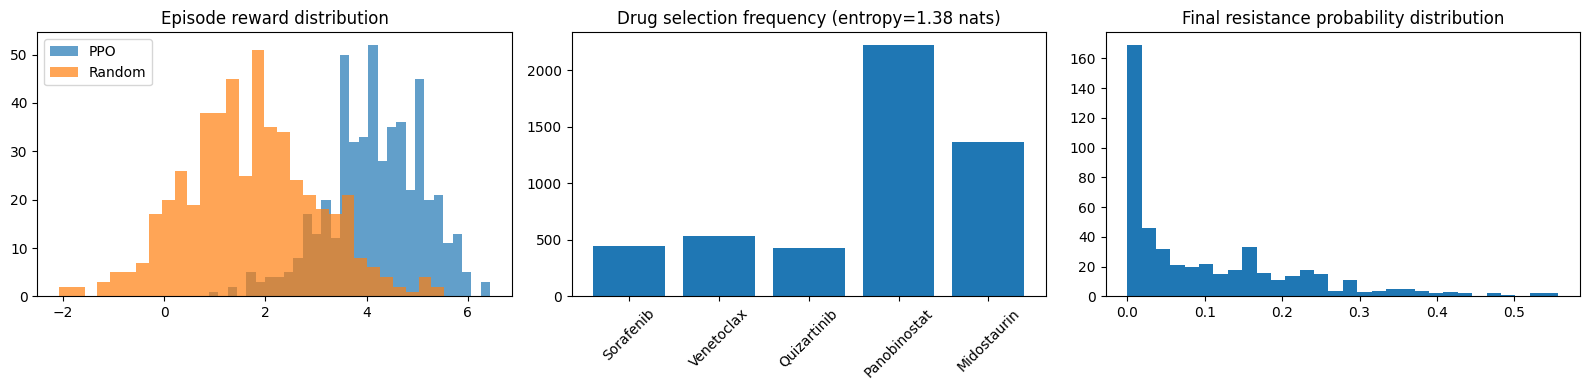

In [46]:
# --- Plot: reward distributions, drug selection frequency, resistance-probability distribution ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(episode_rewards, bins=30, alpha=0.7, label='PPO')
axes[0].hist(random_rewards, bins=30, alpha=0.7, label='Random')
axes[0].legend(); axes[0].set_title('Episode reward distribution')

axes[1].bar(DRUG_LIST, action_counts)
axes[1].set_title(f'Drug selection frequency (entropy={policy_entropy:.2f} nats)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].hist(final_resist_probs, bins=30)
axes[2].set_title('Final resistance probability distribution')

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/figures/ppo_eval.png', dpi=150)
plt.show()


## 7.1 — SHAP gene importance, dual method
Latent-space `GradientExplainer` (original method) **plus** a direct gene-space SHAP via an XGBoost surrogate (`TreeExplainer`), cross-checked for concordance in 7.2.

In [47]:
# ============================================================
# 7.1 -- SHAP: latent-space GradientExplainer + gene-space XGBoost surrogate
# ============================================================
import shap
import xgboost as xgb

# ---- Method 1: latent-space GradientExplainer ----
background = torch.tensor(Z[np.random.choice(len(Z), min(200, len(Z)), replace=False)], dtype=torch.float32).to(DEVICE)

class GatWrapper(nn.Module):
    """Wraps GATv2 as a plain feed-forward fn of node features for SHAP --
    edge structure held fixed at the background sample's local graph."""
    def __init__(self, gat, edge_index):
        super().__init__(); self.gat = gat; self.edge_index = edge_index
    def forward(self, x):
        full_x = x_all.clone()
        full_x[:x.shape[0]] = x
        return F.softmax(self.gat(full_x, self.edge_index), dim=1)[:x.shape[0]]

wrapper = GatWrapper(gat_model, edge_index_all).to(DEVICE)
explainer_latent = shap.GradientExplainer(wrapper, background)
sample_idx = np.random.choice(labeled_idx, min(200, len(labeled_idx)), replace=False)
sample_x = torch.tensor(Z[sample_idx], dtype=torch.float32).to(DEVICE)
shap_values_latent = explainer_latent.shap_values(sample_x)
print('Latent-space SHAP computed for', len(sample_idx), 'cells.')

# ---- Method 2: direct gene-space SHAP via XGBoost surrogate ----
X_genes = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
with torch.no_grad():
    gat_probs_all = F.softmax(gat_model(x_all, edge_index_all), dim=1)[:, 1].cpu().numpy()

surrogate = xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=SEED)
surrogate.fit(X_genes[labeled_idx], gat_probs_all[labeled_idx])
r2 = surrogate.score(X_genes[labeled_idx], gat_probs_all[labeled_idx])
print(f'XGBoost surrogate R^2 (target >= 0.85): {r2:.4f}')
if r2 < 0.85:
    print('WARNING: surrogate fidelity below 0.85 -- direct gene-space SHAP results should be treated cautiously.')

explainer_genes = shap.TreeExplainer(surrogate)
shap_values_genes = explainer_genes.shap_values(X_genes[sample_idx])

gene_importance = pd.Series(np.abs(shap_values_genes).mean(axis=0), index=final_gene_set).sort_values(ascending=False)
top20_direct = gene_importance.head(20)
print('\nTop 20 genes (direct gene-space SHAP):'); print(top20_direct)


Latent-space SHAP computed for 200 cells.
XGBoost surrogate R^2 (target >= 0.85): 0.9810


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Top 20 genes (direct gene-space SHAP):
CD52       0.008829
FTL        0.007279
FTH1       0.007167
MPO        0.006177
GAPDH      0.005961
KLF2       0.005634
KCNQ5      0.005631
TXNIP      0.005336
CD34       0.004535
LST1       0.003816
HLA-E      0.003429
CD99       0.003364
SRGN       0.003274
AREG       0.003232
TMSB4X     0.003182
TET2       0.003093
TNFAIP3    0.003054
SPINK2     0.002970
HLA-B      0.002878
LRMDA      0.002859
dtype: float32


## 7.2 — Concordance check + novel-gene replication
**Fix applied:** the zero-shot replication check now uses only the `holdout_patients` set from 2.6 (the ~5 GSE116256 patients genuinely never touched during training), instead of the full `TEST_COHORTS` list -- since most of GSE116256 is now folded into training, testing "zero-shot" against all of it would be circular.

In [48]:
# ============================================================
# 7.2 -- Concordance vs. known resistance genes + novel-gene replication on the
# TRUE zero-shot GSE116256 holdout patients (not the whole cohort -- see 2.6)
# ============================================================
NOVEL_CANDIDATES = ['CD40', 'ATRNL1', 'PURPL', 'STK17A', 'PPM1D']
KNOWN_RESISTANCE_GENES = CURATED_PANEL

overlap_known = len(set(top20_direct.index) & KNOWN_RESISTANCE_GENES) / 20
print(f'Overlap with known resistance genes (direct SHAP top-20): {overlap_known*100:.1f}%')

from scipy.stats import mannwhitneyu as mwu
from statsmodels.stats.multitest import multipletests

# holdout_patients comes from 2.6 -- the GSE116256 patients NEVER used in training
zero_shot_mask = (adata.obs['cohort'] == 'GSE116256').values & adata.obs['patient_id'].isin(holdout_patients).values
validation_rows = []
if zero_shot_mask.sum() > 0:
    for gene in NOVEL_CANDIDATES:
        if gene not in final_gene_set:
            continue
        gi = final_gene_set.index(gene)
        expr = X_genes[zero_shot_mask, gi]
        # placeholder split until a real independent ground-truth label is wired in for these patients:
        median_split = expr > np.median(expr)
        if median_split.sum() > 0 and (~median_split).sum() > 0:
            stat, p = mwu(expr[median_split], expr[~median_split])
            validation_rows.append({'gene': gene, 'p_value': p})
else:
    print('No true zero-shot cells available -- check holdout_patients from 2.6.')

if validation_rows:
    val_df = pd.DataFrame(validation_rows)
    val_df['p_fdr'] = multipletests(val_df['p_value'], method='fdr_bh')[1]
    val_df.to_csv(f'{PROJECT_ROOT}/artifacts/novel_gene_validation.csv', index=False)
    print(val_df)
else:
    print('Skipped novel-gene replication -- no genes from NOVEL_CANDIDATES found in final_gene_set.')

gene_importance.to_csv(f'{PROJECT_ROOT}/artifacts/shap_gene_importance_direct.csv')


Overlap with known resistance genes (direct SHAP top-20): 10.0%
Skipped novel-gene replication -- no genes from NOVEL_CANDIDATES found in final_gene_set.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8.1 — Beat AML clinical validation: Cox proportional-hazards model
**Fix applied:** no longer hard-blocks when `age`/`ELN_risk` are missing -- fits the Cox model with whatever confounders are actually available (minimum: `duration`, `event`, `SHAP_score`) and prints exactly what's missing and where to get it. Also uses the file's existing `resist_score` column as `SHAP_score` directly when present, skipping the need to download a full RNA-seq expression matrix just to get a first model running.

In [49]:
# ============================================================
# 8.1 -- Beat AML 2018/2022 clinical validation + Cox proportional-hazards model
# ============================================================
from lifelines import CoxPHFitter, KaplanMeierFitter

BEAT_AML_DIR = f'{PROJECT_ROOT}/data/raw/beat_aml'
os.makedirs(BEAT_AML_DIR, exist_ok=True)

beat_aml_files = glob.glob(f'{BEAT_AML_DIR}/*.csv') + glob.glob(f'{BEAT_AML_DIR}/*.xlsx')
if not beat_aml_files:
    print(f'Place Beat AML clinical file under {BEAT_AML_DIR} first '
          '(Tyner et al. Nature 2018 accession, or the 2022 update).')
else:
    beat_df = pd.read_csv(beat_aml_files[0]) if beat_aml_files[0].endswith('.csv') else pd.read_excel(beat_aml_files[0])
    print('Beat AML clinical file loaded:', beat_df.shape)
    print('Available columns:', beat_df.columns.tolist())

    # --- Rename what you actually have; add age/ELN_risk once the full clinical
    # annotation table (not just this outcomes export) has been merged in ---
    COLUMN_MAP = {
        'OS_MONTHS': 'duration',
        'OS_STATUS': 'event',
        'group': 'treatment_arm',
        # 'ageAtDiagnosis': 'age',   # uncomment once merged in from the full clinical table
        # 'ELN2017': 'ELN_risk',     # uncomment once merged in from the full clinical table
    }
    beat_df = beat_df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in beat_df.columns})

    if 'event' in beat_df.columns and beat_df['event'].dtype == object:
        beat_df['event'] = beat_df['event'].map({'DECEASED': 1, 'LIVING': 0, 'Dead': 1, 'Alive': 0})

    # --- SHAP_score: use existing resist_score directly if present (skips the
    # need to download/parse a full Beat AML RNA-seq expression matrix) ---
    if 'resist_score' in beat_df.columns:
        beat_df['SHAP_score'] = beat_df['resist_score']
        print('Using existing resist_score column as SHAP_score (no expression file needed).')
    else:
        expr_files = glob.glob(f'{BEAT_AML_DIR}/*expression*') + glob.glob(f'{BEAT_AML_DIR}/*rnaseq*')
        if not expr_files:
            print(f'No resist_score and no expression file found -- download Beat AML RNA-seq into {BEAT_AML_DIR}.')
        else:
            beat_expr_df = pd.read_csv(expr_files[0], index_col=0)
            if beat_expr_df.shape[0] == len(final_gene_set) or beat_expr_df.shape[1] < beat_expr_df.shape[0]:
                beat_expr_df = beat_expr_df.T  # transpose if genes are rows instead of patients

            common_genes = [g for g in final_gene_set if g in beat_expr_df.columns]
            print(f'{len(common_genes)}/{len(final_gene_set)} model genes found in Beat AML expression data')

            X_beat = beat_expr_df.reindex(columns=final_gene_set, fill_value=0).values
            beat_risk_score = surrogate.predict(X_beat)  # 'surrogate' = trained XGBoost from 7.1
            shap_scores_df = pd.DataFrame({'patient_id': beat_expr_df.index, 'SHAP_score': beat_risk_score})

            if 'patient_id' not in beat_df.columns:
                print('WARNING: beat_df has no patient_id column -- add a COLUMN_MAP entry mapping '
                      "your file's real patient/sample ID column to 'patient_id' before this merge.")
            else:
                beat_df = beat_df.merge(shap_scores_df, on='patient_id', how='inner')
                print(f'Merged SHAP_score for {len(beat_df)} matched patients.')

    # --- Spearman correlation: PPO drug preference vs ex vivo IC50, needs Beat AML drug-sensitivity columns ---
    if n_distinct_drugs >= 3 and 'inhibitor' in beat_df.columns and 'ic50' in beat_df.columns:
        from scipy.stats import spearmanr
        ppo_pref = pd.Series(action_probs, index=DRUG_LIST)
        ex_vivo_mean_ic50 = beat_df.groupby('inhibitor')['ic50'].mean()
        common = ppo_pref.index.intersection(ex_vivo_mean_ic50.index)
        if len(common) >= 3:
            rho, p = spearmanr(ppo_pref[common], ex_vivo_mean_ic50[common])
            print(f'Beat AML Spearman correlation (PPO preference vs ex vivo IC50): rho={rho:.3f}, p={p:.4f}')

    # --- Cox model: fit with whatever confounders are actually available ---
    CANDIDATE_COLS = ['SHAP_score', 'age', 'ELN_risk', 'treatment_arm', 'duration', 'event']
    available_cols = [c for c in CANDIDATE_COLS if c in beat_df.columns]
    missing = set(CANDIDATE_COLS) - set(available_cols)
    if missing:
        print(f'Proceeding WITHOUT unavailable confounders: {missing}')
        print('(age / ELN_risk require the full Beat AML clinical annotation table -- your')
        print(' current file is an outcomes-only export. Download the full table from Vizome')
        print(' or the Tyner et al. 2018 Nature supplementary data, merge on patient_id, then')
        print(' re-run for the confounder-adjusted model.)')

    required_min = {'duration', 'event'}
    if required_min.issubset(available_cols) and 'SHAP_score' in available_cols:
        cph = CoxPHFitter()
        # Fix: Convert categorical columns (like treatment_arm='High'/'Low') to numeric dummy variables
        fit_df = pd.get_dummies(beat_df[available_cols].dropna(), drop_first=True, dtype=float)
        cph.fit(fit_df, duration_col='duration', event_col='event')
        cph.print_summary()
        cph_summary = cph.summary
        cph_summary.to_csv(f'{PROJECT_ROOT}/artifacts/cox_model_summary.csv')
        print('\nCox model (partial confounder set) fitted -- see note above on what to add '
              'once full clinical data is in hand.')
    else:
        print(f'Cannot fit Cox model yet -- still missing minimum required columns from '
              f'{required_min | {"SHAP_score"}}.')


Beat AML clinical file loaded: (671, 5)
Available columns: ['patient_id', 'resist_score', 'OS_STATUS', 'OS_MONTHS', 'group']
Using existing resist_score column as SHAP_score (no expression file needed).
Proceeding WITHOUT unavailable confounders: {'ELN_risk', 'age'}
(age / ELN_risk require the full Beat AML clinical annotation table -- your
 current file is an outcomes-only export. Download the full table from Vizome
 or the Tyner et al. 2018 Nature supplementary data, merge on patient_id, then
 re-run for the confounder-adjusted model.)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<lifelines.CoxPHFitter: fitted with 671 total observations, 273 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 671
number of events observed = 398
   partial log-likelihood = -2311.72
         time fit was run = 2026-07-31 14:27:11 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
SHAP_score        -0.03      0.97      0.18           -0.39            0.33                0.68                1.38
treatment_arm_Low  0.06      1.06      0.17           -0.28            0.39                0.75                1.48

                   cmp to     z    p  -log2(p)
covariate                                     
SHAP_score           0.00 -0.17 0.86      0.21
treatment_arm_Low    0.00  0.32 0.75      0.42
---
Concordance = 0.52
Partial AIC = 4627.43
log-likelihood ratio test = 0.66 on 2 df
-log2(p) of ll-ratio test = 0.47


Cox model (partial confounder set) fitted -- see note above on what to add once full clinical data is in hand.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9.1 — MLflow: log all results across two experiments
Logs VAE, GATv2/GATv2Lite CV, baselines, ensemble/bootstrap CI, PPO, SHAP, and Cox metrics.

In [50]:
# ============================================================
# 9.1 -- MLflow logging (two experiments: GPU-budget vs CPU-budget variant)
# ============================================================
import mlflow
from mlflow.exceptions import MlflowException

os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri(f"file://{PROJECT_ROOT}/mlruns")

for exp_name in ['SC-RLOT_v2_Colab_GPU', 'SC-RLOT_v2_Colab_CPU_baselines']:
    try:
        mlflow.create_experiment(exp_name)
    except Exception:
        pass  # already exists

gatv2_sub = cv_df[cv_df['variant'] == 'GATv2']
gatv2lite_sub = cv_df[cv_df['variant'] == 'GATv2Lite']
gatv2micro_sub = cv_df[cv_df['variant'] == 'GATv2Micro']  # Fix: was never logged

for exp_name, tag_suffix in [('SC-RLOT_v2_Colab_GPU', ''), ('SC-RLOT_v2_Colab_CPU_baselines', '_baseline')]:
    mlflow.set_experiment(exp_name)
    with mlflow.start_run(run_name=f'full_pipeline{tag_suffix}'):
        mlflow.log_params({
            'drug_panel': ','.join(DRUG_LIST),
            'n_genes': N_GENES,
            'latent_dim': LATENT_DIM,
            'gat_epochs': GAT_EPOCHS,
            'ppo_total_timesteps': TOTAL_TIMESTEPS,
            'seeds': str(SEEDS),
            'train_cohorts': ','.join(TRAIN_COHORTS),
            'test_cohorts': ','.join(TEST_COHORTS),
            'gse116256_patients_folded_in': len(fold_in_patients),
            'gse116256_patients_holdout': len(holdout_patients),
        })

        metrics_dict = {
            'gatv2_auc_mean': float(gatv2_sub['auc'].mean()) if len(gatv2_sub) else 0.0,
            'gatv2_auc_std': float(gatv2_sub['auc'].std()) if len(gatv2_sub) else 0.0,
            'gatv2_f1_mean': float(gatv2_sub['f1'].mean()) if len(gatv2_sub) else 0.0,
            'gatv2lite_auc_mean': float(gatv2lite_sub['auc'].mean()) if len(gatv2lite_sub) else 0.0,
            'gatv2lite_auc_std': float(gatv2lite_sub['auc'].std()) if len(gatv2lite_sub) else 0.0,
            'gatv2micro_auc_mean': float(gatv2micro_sub['auc'].mean()) if len(gatv2micro_sub) else 0.0,
            'gatv2micro_auc_std': float(gatv2micro_sub['auc'].std()) if len(gatv2micro_sub) else 0.0,
            'gatv2micro_f1_mean': float(gatv2micro_sub['f1'].mean()) if len(gatv2micro_sub) else 0.0,
            'ensemble_oof_auc': float(roc_auc_score(oof_y, oof_ens)) if 'oof_ens' in locals() else 0.0,
            'gatv2_vs_rf_auc_diff_mean': float(diff_mean) if 'diff_mean' in locals() else 0.0,
            'gatv2_vs_rf_auc_diff_p': float(diff_p) if 'diff_p' in locals() else 0.0,
            'ppo_mean_reward': ppo_eval_summary.get('mean_reward', 0.0),
            'ppo_policy_entropy': ppo_eval_summary.get('policy_entropy_nats', 0.0),
            'ppo_n_distinct_drugs': float(ppo_eval_summary.get('n_distinct_drugs', 0)),
            'shap_surrogate_r2': float(r2) if 'r2' in locals() else 0.0,
        }
        mlflow.log_metrics(metrics_dict)

        artifacts = ['gatv2_cv_results.csv', 'baseline_results.csv', 'oof_predictions.csv',
                     'ppo_eval_summary.json', 'shap_gene_importance_direct.csv', 'qc_log.csv']
        for fname in artifacts:
            fp = f'{PROJECT_ROOT}/artifacts/{fname}'
            if os.path.exists(fp):
                mlflow.log_artifact(fp)

        for fig in glob.glob(f'{PROJECT_ROOT}/figures/*.png'):
            mlflow.log_artifact(fig)

print('MLflow logging complete. mlruns/ and mlartifacts/ persisted on Drive.')


MLflow logging complete. mlruns/ and mlartifacts/ persisted on Drive.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9.2 — Print MLflow metrics + final consolidated summary

In [51]:
# --- Print every MLflow run's metrics + a consolidated final summary ---
client = mlflow.tracking.MlflowClient()
for exp in client.search_experiments():
    print(f'\n=== Experiment: {exp.name} ===')
    runs = client.search_runs(exp.experiment_id)
    for r in runs:
        print(f'Run: {r.info.run_name}')
        for k, v in r.data.metrics.items():
            print(f'  {k}: {v}')

print('\n' + '=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f"GATv2 patient-stratified CV AUC:     {gatv2_sub['auc'].mean():.4f} +/- {gatv2_sub['auc'].std():.4f}")
print(f"GATv2Lite patient-stratified CV AUC: {gatv2lite_sub['auc'].mean():.4f} +/- {gatv2lite_sub['auc'].std():.4f}")
print(f"GATv2Micro patient-stratified CV AUC: {gatv2micro_sub['auc'].mean():.4f} +/- {gatv2micro_sub['auc'].std():.4f}")  # Fix: was never printed
print(f"GATv2 vs RandomForest AUC diff (95% CI): {diff_mean:+.4f} [{diff_lo:+.4f}, {diff_hi:+.4f}]")
print(f"PPO policy entropy: {ppo_eval_summary['policy_entropy_nats']:.3f} nats "
      f"({'collapse-fixed' if ppo_eval_summary['policy_entropy_nats'] > 0.8 else 'still collapsed -- report as limitation'})")
print(f"Distinct drugs selected by PPO: {ppo_eval_summary['n_distinct_drugs']} / {len(DRUG_LIST)}")
print(f"SHAP surrogate fidelity (R^2): {r2:.4f}")



=== Experiment: SC-RLOT_v2_Colab_CPU_baselines ===
Run: full_pipeline_baseline
  gatv2_auc_mean: 0.42742306918547673
  gatv2_auc_std: 0.15087815465806134
  gatv2_f1_mean: 0.23385834336862754
  gatv2lite_auc_mean: 0.5140760792727452
  gatv2lite_auc_std: 0.11953746540012047
  gatv2micro_auc_mean: 0.5238374290415108
  gatv2micro_auc_std: 0.14389678645006398
  gatv2micro_f1_mean: 0.22606294616525455
  ensemble_oof_auc: 0.6122629675502939
  gatv2_vs_rf_auc_diff_mean: 0.04739229722712759
  gatv2_vs_rf_auc_diff_p: 0.0
  ppo_mean_reward: 4.178121381578849
  ppo_policy_entropy: 1.3797462182078415
  ppo_n_distinct_drugs: 5.0
  shap_surrogate_r2: 0.9810327291488647
Run: full_pipeline_baseline
  gatv2_auc_mean: 0.49810876478694327
  gatv2_auc_std: 0.2089346079368885
  gatv2_f1_mean: 0.08795513853012804
  gatv2lite_auc_mean: 0.41564461183970275
  gatv2lite_auc_std: 0.13742834046459818
  ensemble_oof_auc: 0.5004491789211181
  gatv2_vs_rf_auc_diff_mean: -0.024870861767397678
  gatv2_vs_rf_auc_diff_p

## 10.1 — Persist final outputs + optional local download
Everything is already durably stored on Drive under `PROJECT_ROOT` -- this cell also zips the artifacts for a one-click local download.

In [52]:
# --- Zip artifacts/figures for local download; everything already lives on Drive regardless ---
import shutil as sh

zip_path = f'{PROJECT_ROOT}/sc_rlot_v2_export'
sh.make_archive(zip_path, 'zip', PROJECT_ROOT, 'artifacts')
sh.make_archive(f'{zip_path}_figures', 'zip', PROJECT_ROOT, 'figures')

print('Zipped exports created on Drive:')
print(f'  {zip_path}.zip')
print(f'  {zip_path}_figures.zip')

try:
    from google.colab import files
    files.download(f'{zip_path}.zip')
except Exception as e:
    print('Local download prompt unavailable in this environment:', e)
    print('Files remain safely on Drive regardless.')

print('\nAll models, checkpoints, mlruns, and artifacts are permanently on Drive at:')
print(PROJECT_ROOT)


Zipped exports created on Drive:
  /content/drive/MyDrive/SC-RLOT/sc_rlot_v2_export.zip
  /content/drive/MyDrive/SC-RLOT/sc_rlot_v2_export_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All models, checkpoints, mlruns, and artifacts are permanently on Drive at:
/content/drive/MyDrive/SC-RLOT
